In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost \
             imbalanced-learn shap plotly streamlit pyngrok openpyxl -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
warnings.filterwarnings('ignore')

# Plotting config
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

# ML Libraries
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

print("✅ All libraries imported successfully!")
print(f"  pandas  : {pd.__version__}")
print(f"  sklearn : {__import__('sklearn').__version__}")
print(f"  xgboost : {xgb.__version__}")

✅ All libraries imported successfully!
  pandas  : 2.2.2
  sklearn : 1.6.1
  xgboost : 3.2.0


**Load Dataset**

In [ ]:
# ── Option A: Upload from your computer ─────────────────────────
from google.colab import files
print("📂 Please upload APL_Logistics.csv when prompted...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='latin1')

# ── Option B: If already in /content (drag-drop to Files panel) ──
# df = pd.read_csv('/content/APL_Logistics.csv', encoding='latin1')

print(f"\n✅ Dataset loaded!")
print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

📂 Please upload APL_Logistics.csv when prompted...


Saving APL_Logistics.csv to APL_Logistics (1).csv

✅ Dataset loaded!
   Shape   : 180,519 rows × 40 columns

📋 Columns:
    1. Type
    2. Days for shipping (real)
    3. Days for shipment (scheduled)
    4. Benefit per order
    5. Sales per customer
    6. Delivery Status
    7. Late_delivery_risk
    8. Category Id
    9. Category Name
   10. Customer City
   11. Customer Country
   12. Customer Fname
   13. Customer Id
   14. Customer Lname
   15. Customer Segment
   16. Customer State
   17. Customer Street
   18. Customer Zipcode
   19. Department Id
   20. Department Name
   21. Latitude
   22. Longitude
   23. Market
   24. Order City
   25. Order Country
   26. Order Customer Id
   27. Order Item Discount
   28. Order Item Discount Rate
   29. Order Item Product Price
   30. Order Item Profit Ratio
   31. Order Item Quantity
   32. Sales
   33. Order Item Total
   34. Order Profit Per Order
   35. Order Region
   36. Order State
   37. Order Status
   38. Product Name
   39. P

**EDA: Basic Overview & Missing Values**

In [ ]:
print("=" * 65)
print("  DATASET OVERVIEW")
print("=" * 65)

print(f"\n🔢 Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

print("\n📊 Data Types:")
type_summary = df.dtypes.value_counts()
for dtype, cnt in type_summary.items():
    print(f"   {str(dtype):12s} → {cnt} columns")

print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("   ✅ No significant missing values")

print("\n📈 Numerical Statistics:")
df.describe().round(2)

  DATASET OVERVIEW

🔢 Shape: 180,519 rows  ×  40 columns

📊 Data Types:
   object       → 19 columns
   float64      → 13 columns
   int64        → 8 columns

🔍 Missing Values:
                  Count  Pct
Customer Lname        8  0.0
Customer Zipcode      3  0.0

📈 Numerical Statistics:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180516.00,180519.00,180519.00,...,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,35921.13,5.44,29.72,...,6691.38,20.66,0.10,141.23,0.12,2.13,203.77,183.11,21.97,141.23
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,37542.46,1.63,9.81,...,4162.92,21.80,0.07,139.73,0.47,1.45,132.27,120.04,104.43,139.73
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,603.00,2.00,-33.94,...,1.00,0.00,0.00,9.99,-2.75,1.00,9.99,7.49,-4274.98,9.99
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,725.00,4.00,18.27,...,3258.50,5.40,0.04,50.00,0.08,1.00,119.98,104.38,7.00,50.00
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,19380.00,5.00,33.14,...,6457.00,14.00,0.10,59.99,0.27,1.00,199.92,163.99,31.52,59.99
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,78207.00,7.00,39.28,...,9779.00,29.99,0.16,199.99,0.36,3.00,299.95,247.40,64.80,199.99
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,99205.00,12.00,48.78,...,20757.00,500.00,0.25,1999.99,0.50,5.00,1999.99,1939.99,911.80,1999.99


**EDA: Target Variable Distribution**

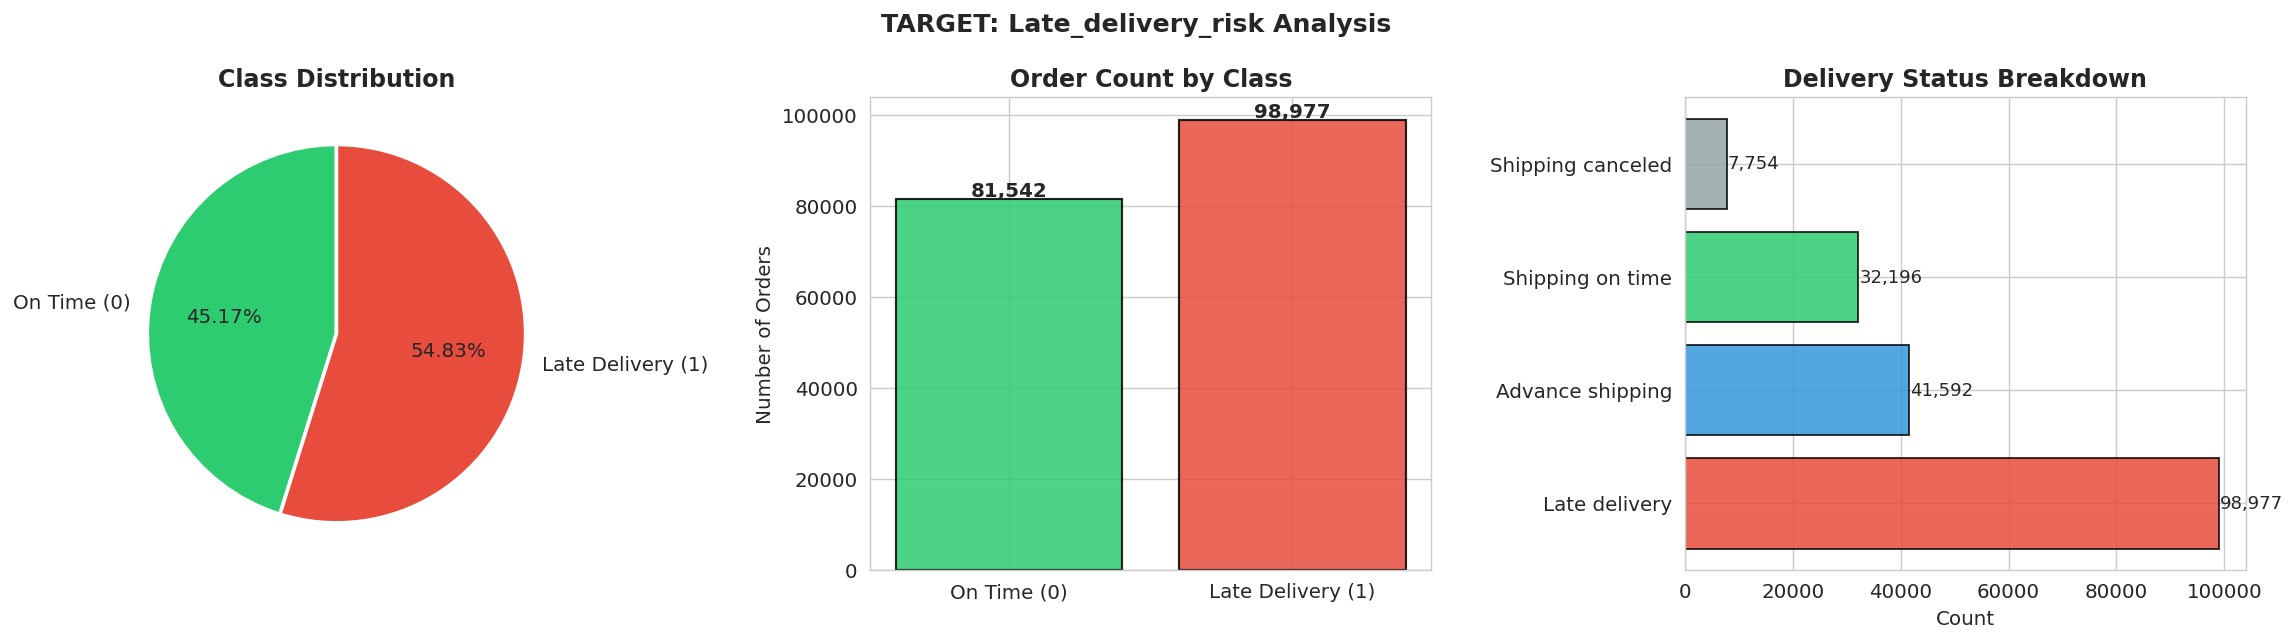


📊 Class Distribution:
   On Time (0) : 81,542  (45.17%)
   Late    (1) : 98,977  (54.83%)

   ⚠️  Class imbalance ratio: 1.214


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TARGET: Late_delivery_risk Analysis', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
target_counts = df['Late_delivery_risk'].value_counts().sort_index()
labels = ['On Time (0)', 'Late Delivery (1)']

# Pie chart
axes[0].pie(target_counts, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution', fontweight='bold')

# Bar chart with counts
bars = axes[1].bar(labels, target_counts.values, color=colors,
                   edgecolor='black', linewidth=1.2, alpha=0.85)
axes[1].set_title('Order Count by Class', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
for bar, val in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')

# Delivery Status breakdown
delivery_counts = df['Delivery Status'].value_counts()
colors_d = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
axes[2].barh(delivery_counts.index, delivery_counts.values,
             color=colors_d, edgecolor='black', alpha=0.85)
axes[2].set_title('Delivery Status Breakdown', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(delivery_counts.values):
    axes[2].text(v + 200, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Class Distribution:")
print(f"   On Time (0) : {target_counts[0]:,}  ({target_counts[0]/len(df)*100:.2f}%)")
print(f"   Late    (1) : {target_counts[1]:,}  ({target_counts[1]/len(df)*100:.2f}%)")
print(f"\n   ⚠️  Class imbalance ratio: {target_counts[1]/target_counts[0]:.3f}")

**EDA: Shipping & Market Analysis**

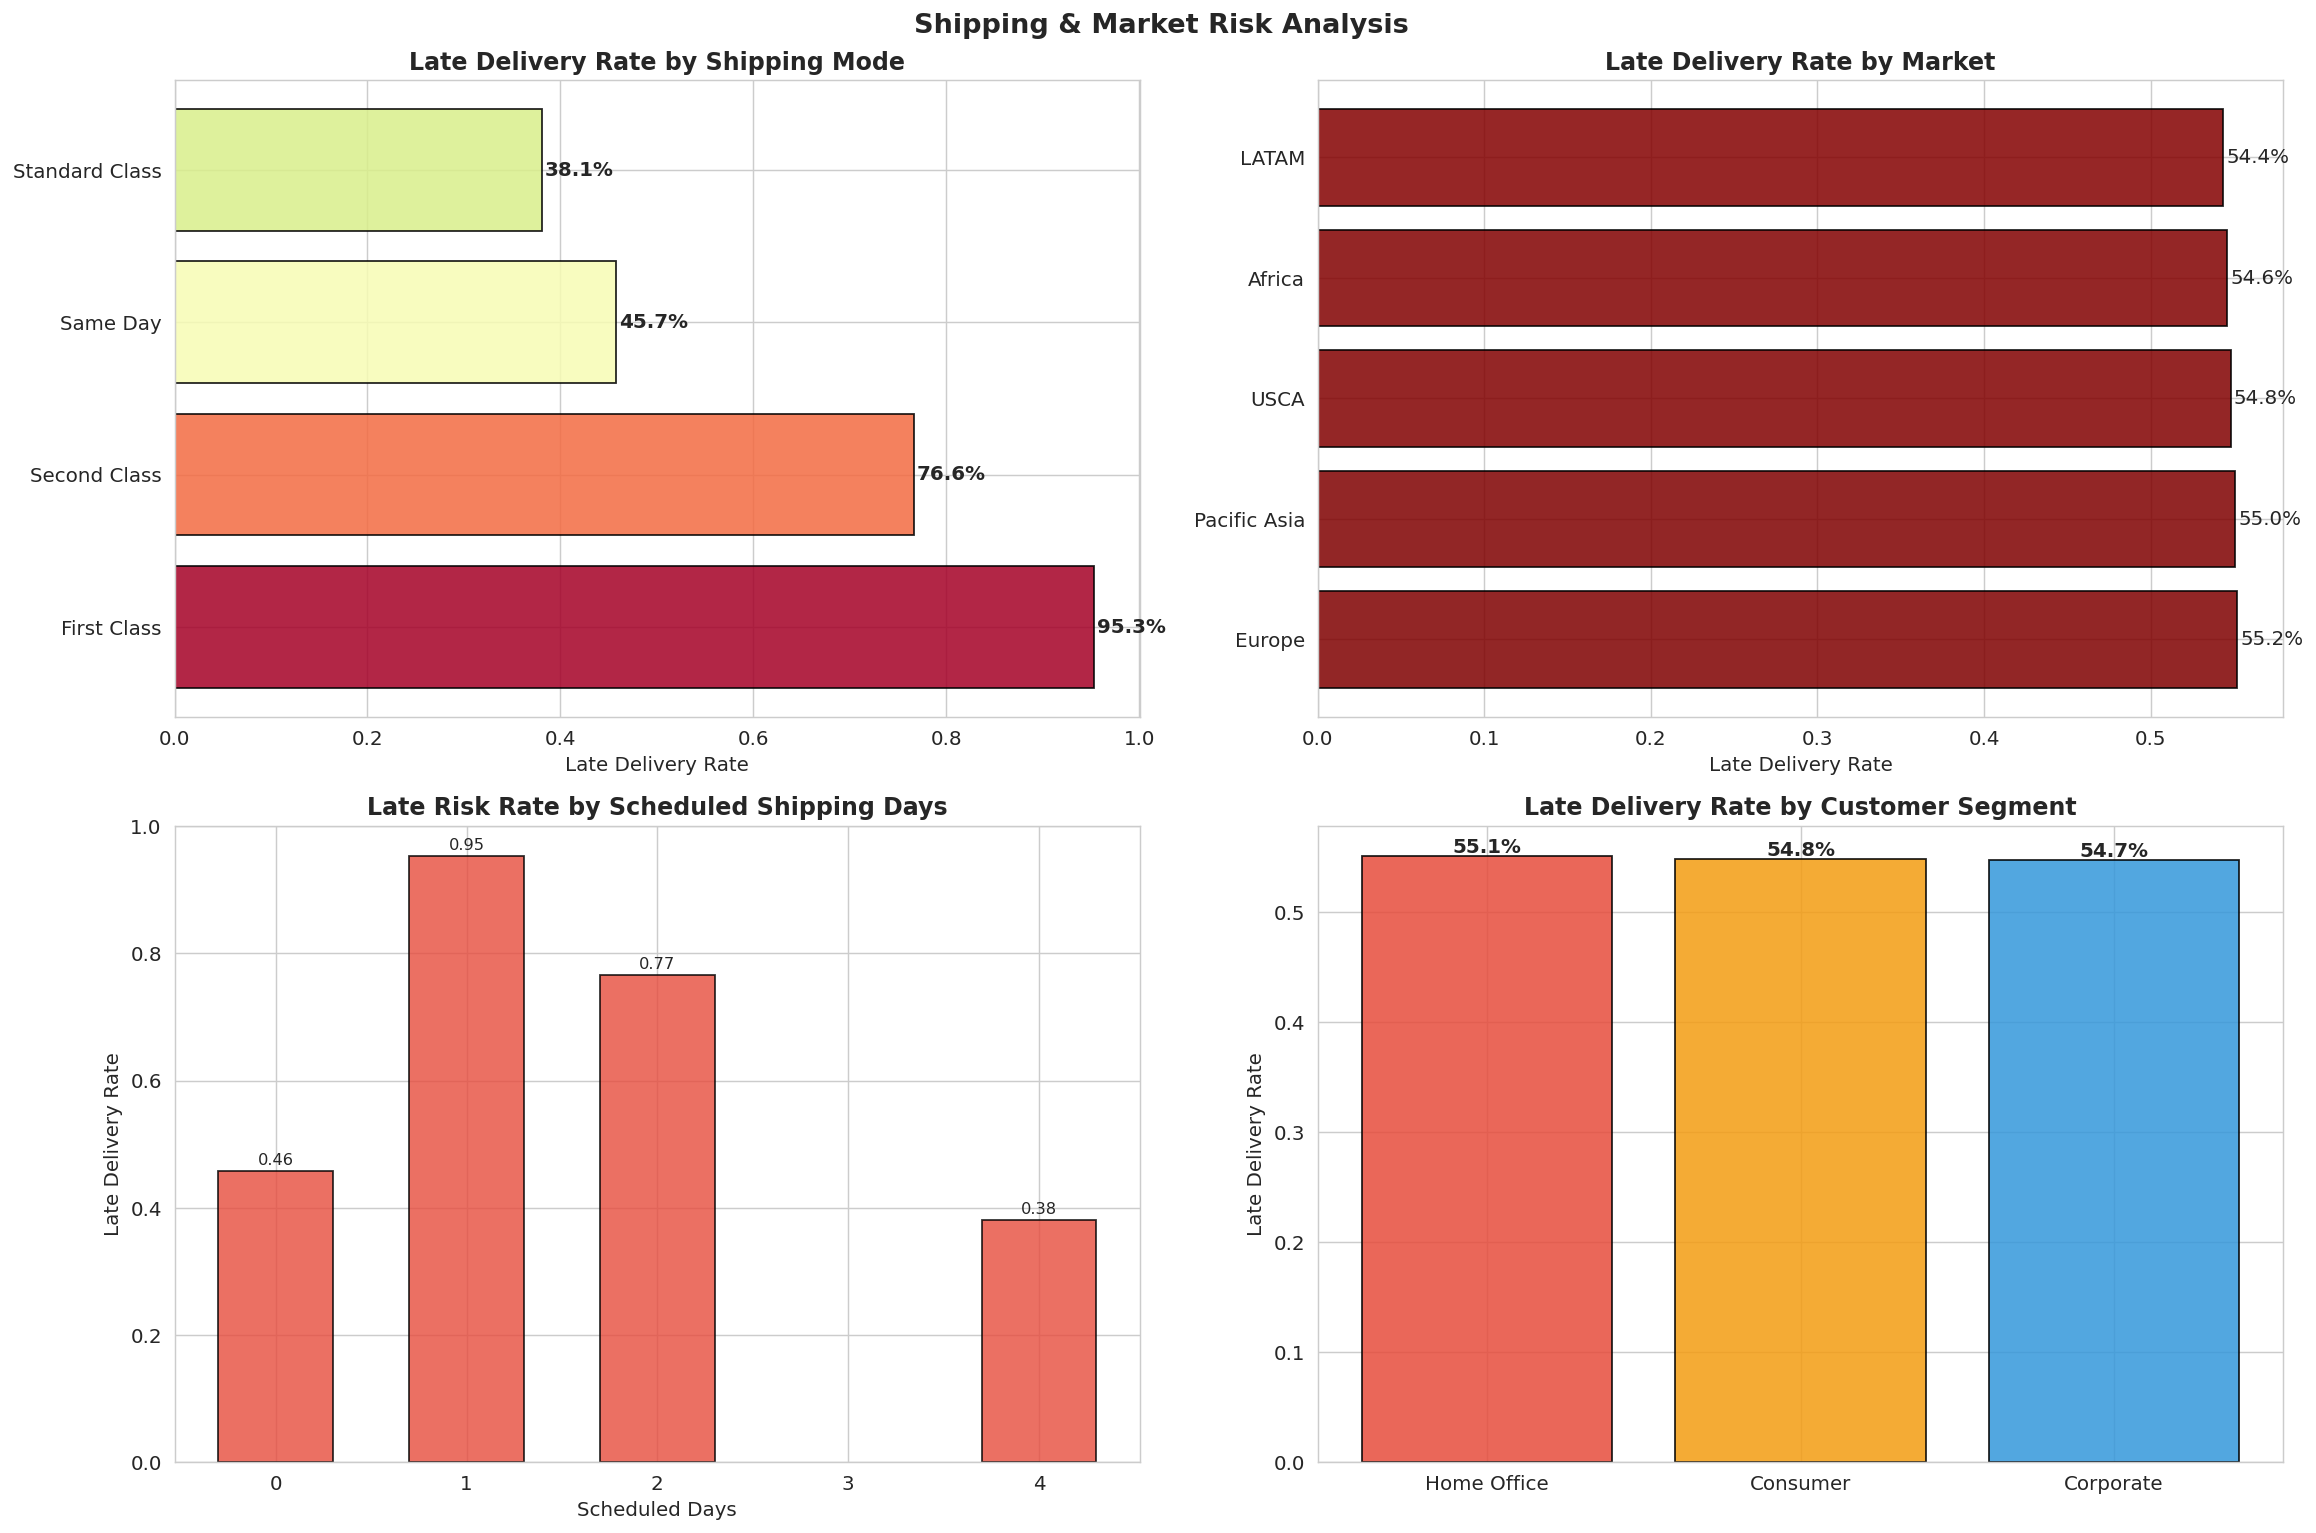

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Shipping & Market Risk Analysis', fontsize=15, fontweight='bold')

# 1. Shipping Mode vs Late Risk
mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
bars1 = axes[0][0].barh(mode_risk.index, mode_risk.values,
                        color=plt.cm.RdYlGn_r(mode_risk.values / mode_risk.max()),
                        edgecolor='black', alpha=0.85)
axes[0][0].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[0][0].set_xlabel('Late Delivery Rate')
for i, v in enumerate(mode_risk.values):
    axes[0][0].text(v + 0.003, i, f'{v:.1%}', va='center', fontweight='bold')

# 2. Market vs Late Risk
market_risk = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
axes[0][1].barh(market_risk.index, market_risk.values,
                color=plt.cm.OrRd(market_risk.values / market_risk.max()),
                edgecolor='black', alpha=0.85)
axes[0][1].set_title('Late Delivery Rate by Market', fontweight='bold')
axes[0][1].set_xlabel('Late Delivery Rate')
for i, v in enumerate(market_risk.values):
    axes[0][1].text(v + 0.002, i, f'{v:.1%}', va='center')

# 3. Scheduled Days vs Late Risk
sched_risk = df.groupby('Days for shipment (scheduled)')['Late_delivery_risk'].mean()
bar3 = axes[1][0].bar(sched_risk.index, sched_risk.values,
                      color='#e74c3c', edgecolor='black', alpha=0.8, width=0.6)
axes[1][0].set_title('Late Risk Rate by Scheduled Shipping Days', fontweight='bold')
axes[1][0].set_xlabel('Scheduled Days')
axes[1][0].set_ylabel('Late Delivery Rate')
for bar, val in zip(bar3, sched_risk.values):
    axes[1][0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f'{val:.2f}',
                    ha='center', fontsize=9)

# 4. Customer Segment vs Late Risk
seg_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)
axes[1][1].bar(seg_risk.index, seg_risk.values,
               color=['#e74c3c', '#f39c12', '#3498db'],
               edgecolor='black', alpha=0.85)
axes[1][1].set_title('Late Delivery Rate by Customer Segment', fontweight='bold')
axes[1][1].set_ylabel('Late Delivery Rate')
for i, v in enumerate(seg_risk.values):
    axes[1][1].text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('shipping_market_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**EDA: Regional & Order Status Analysis**

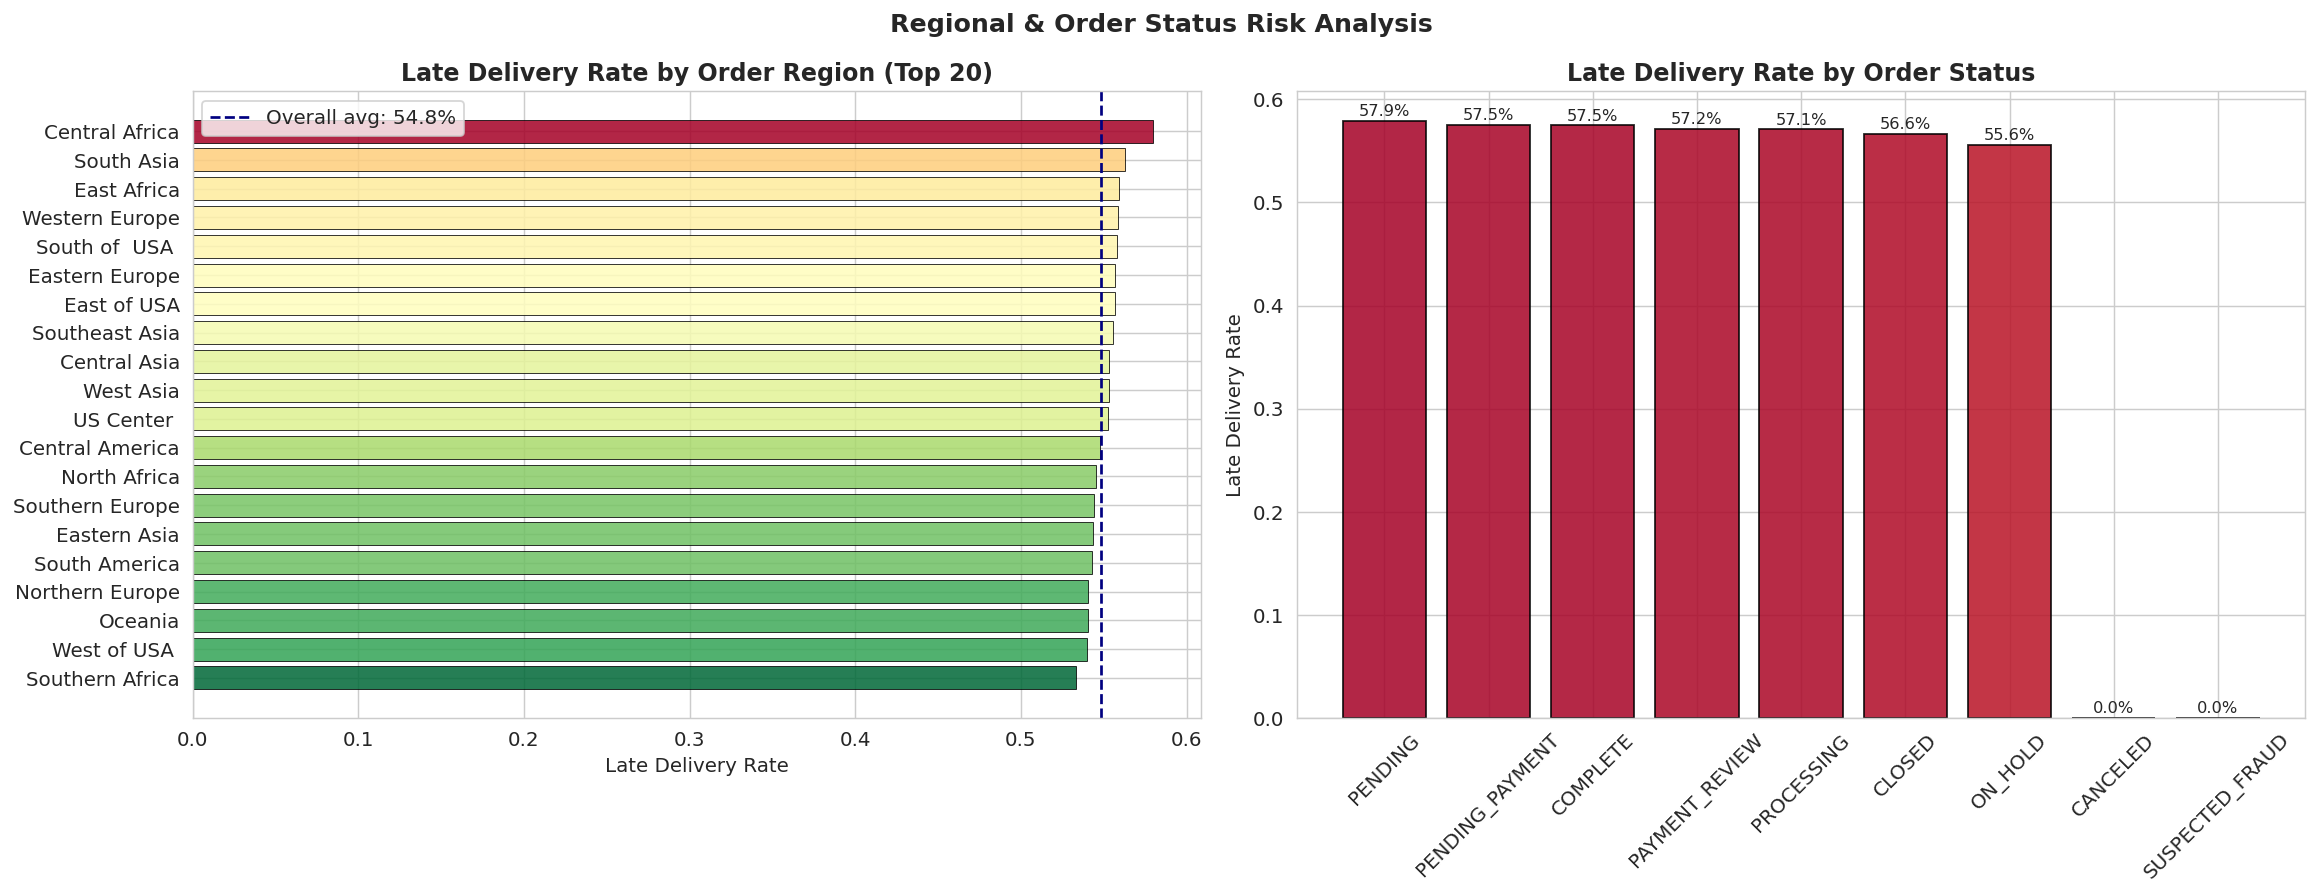

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Regional & Order Status Risk Analysis', fontsize=14, fontweight='bold')

# Region risk (top 20)
region_risk = (df.groupby('Order Region')['Late_delivery_risk']
               .mean().sort_values(ascending=True).tail(20))
colors_r = plt.cm.RdYlGn_r(
    (region_risk.values - region_risk.min()) /
    (region_risk.max() - region_risk.min())
)
axes[0].barh(region_risk.index, region_risk.values,
             color=colors_r, edgecolor='black', linewidth=0.5, alpha=0.85)
axes[0].set_title('Late Delivery Rate by Order Region (Top 20)', fontweight='bold')
axes[0].set_xlabel('Late Delivery Rate')
axes[0].axvline(x=df['Late_delivery_risk'].mean(),
                color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {df["Late_delivery_risk"].mean():.1%}')
axes[0].legend()

# Order Status risk
status_risk = (df.groupby('Order Status')['Late_delivery_risk']
               .mean().sort_values(ascending=False))
axes[1].bar(status_risk.index, status_risk.values,
            color=plt.cm.RdYlGn_r(
                (status_risk.values - status_risk.min()) /
                (status_risk.max() - status_risk.min())
            ),
            edgecolor='black', alpha=0.85)
axes[1].set_title('Late Delivery Rate by Order Status', fontweight='bold')
axes[1].set_ylabel('Late Delivery Rate')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(status_risk.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('regional_order_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**EDA: Correlation Matrix**

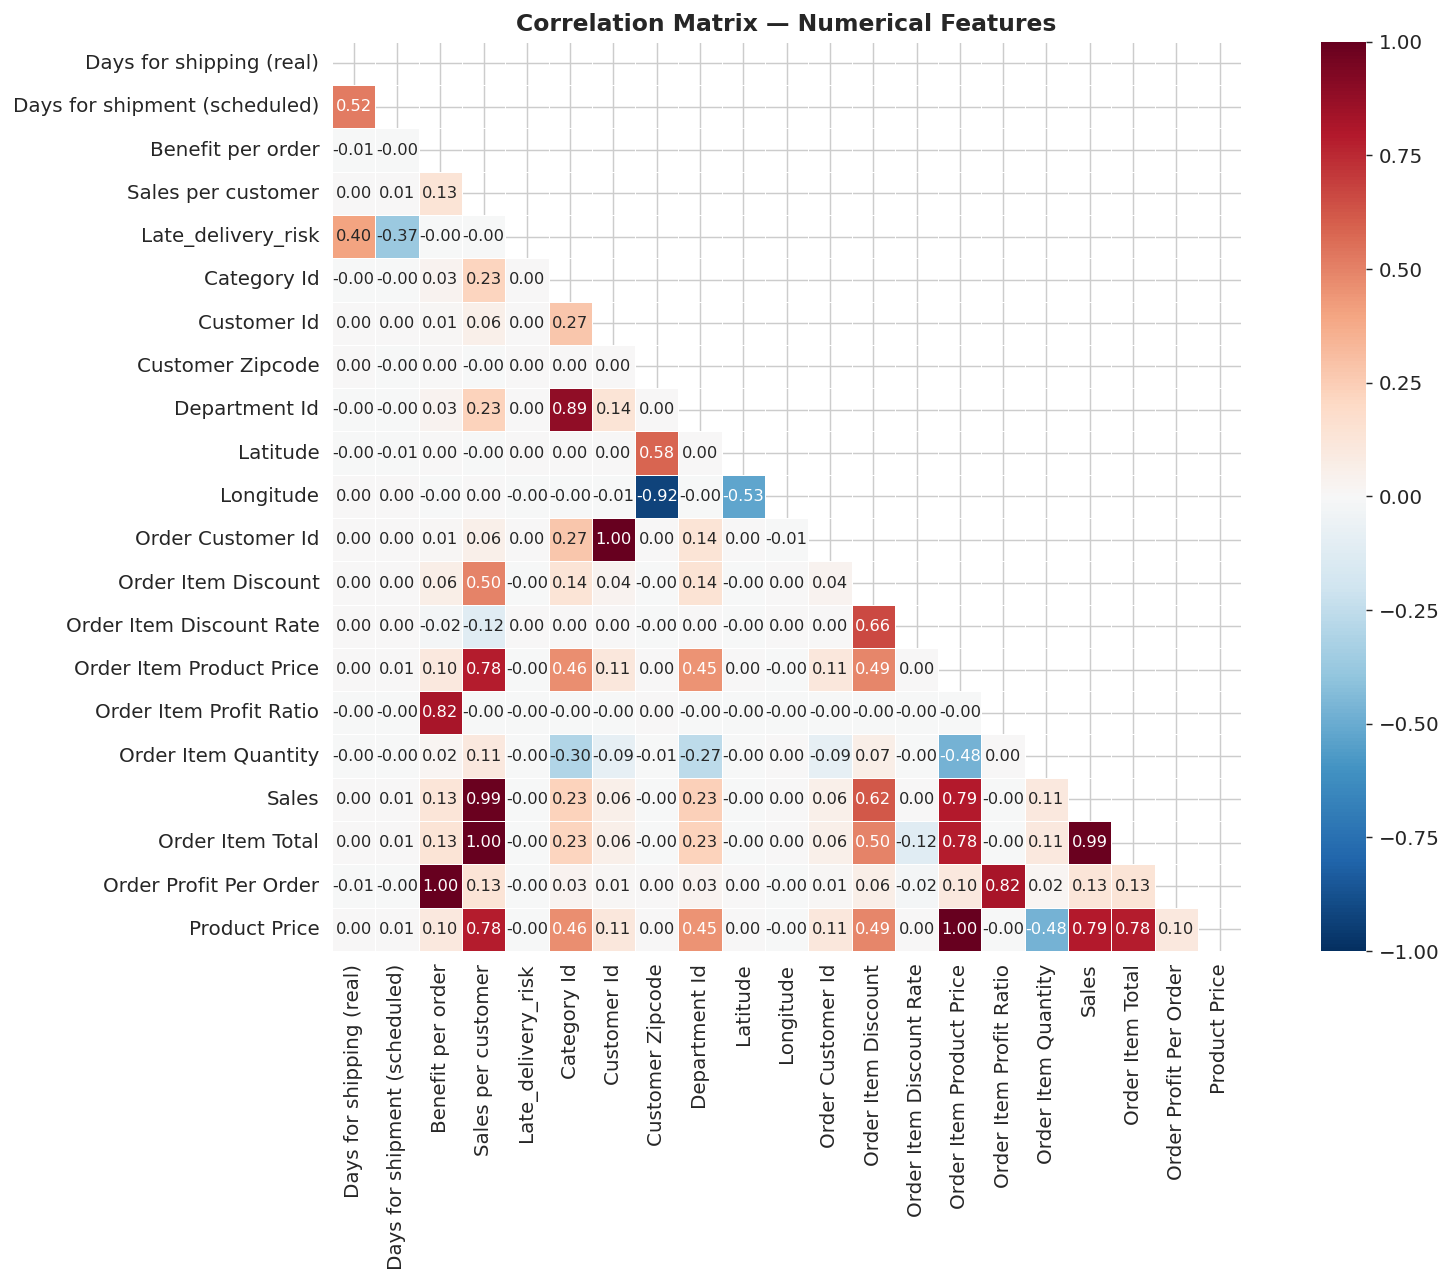

📊 Feature Correlations with Late_delivery_risk (sorted):
Days for shipment (scheduled)   -0.369352
Order Item Total                -0.003791
Sales per customer              -0.003791
Benefit per order               -0.003727
Order Profit Per Order          -0.003727
Sales                           -0.003564
Order Item Profit Ratio         -0.002316
Order Item Product Price        -0.002175
Product Price                   -0.002175
Longitude                       -0.001915
Order Item Discount             -0.000750
Order Item Quantity             -0.000139
Order Item Discount Rate         0.000404
Latitude                         0.000679
Department Id                    0.001077
Customer Id                      0.001484
Order Customer Id                0.001484
Category Id                      0.001752
Customer Zipcode                 0.003148
Days for shipping (real)         0.401415


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
heatmap = sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Target correlations
print("📊 Feature Correlations with Late_delivery_risk (sorted):")
target_corr = corr_matrix['Late_delivery_risk'].drop('Late_delivery_risk').sort_values()
print(target_corr.to_string())

**Data Preprocessing**

In [ ]:
print("🧹 Starting Data Preprocessing...\n")

df_clean = df.copy()

# ── Step 1: Drop Data Leakage Columns ───────────────────────────
# 'Delivery Status' encodes the target directly (Late delivery = 1)
# 'Days for shipping (real)' is post-delivery info — not available before shipment
LEAKAGE_COLS = ['Delivery Status', 'Days for shipping (real)']

# ── Step 2: Drop PII / Non-predictive Columns ───────────────────
PII_COLS = [
    'Customer Fname', 'Customer Lname', 'Customer Street',
    'Customer Zipcode', 'Customer Id', 'Order Customer Id'
]

# ── Step 3: Drop Redundant IDs ──────────────────────────────────
REDUNDANT_COLS = ['Category Id', 'Department Id']

ALL_DROP = LEAKAGE_COLS + PII_COLS + REDUNDANT_COLS
df_clean = df_clean.drop(columns=ALL_DROP, errors='ignore')

print(f"  Original shape     : {df.shape}")
print(f"  After dropping cols: {df_clean.shape}")
print(f"\n  ⚠️  Dropped {len(ALL_DROP)} columns:")
for col in ALL_DROP:
    print(f"       – {col}")

# ── Step 4: Handle Missing Values ───────────────────────────────
print(f"\n  Missing values before cleaning:")
missing = df_clean.isnull().sum()
print(f"  {missing[missing > 0].to_dict()}")

# Fill the tiny number of missing values
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna('Unknown')
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\n  Missing after cleaning: {df_clean.isnull().sum().sum()}")
print(f"\n  ✅ Final clean shape: {df_clean.shape}")

🧹 Starting Data Preprocessing...

  Original shape     : (180519, 40)
  After dropping cols: (180519, 30)

  ⚠️  Dropped 10 columns:
       – Delivery Status
       – Days for shipping (real)
       – Customer Fname
       – Customer Lname
       – Customer Street
       – Customer Zipcode
       – Customer Id
       – Order Customer Id
       – Category Id
       – Department Id

  Missing values before cleaning:
  {}

  Missing after cleaning: 0

  ✅ Final clean shape: (180519, 30)


**Feature Engineering**

In [ ]:
print("🔧 Engineering predictive features...\n")

# ─── 1. Shipping Pressure Index ─────────────────────────────────
#        How many items crammed into how few scheduled days?
df_clean['shipping_pressure'] = (
    df_clean['Order Item Quantity'] /
    (df_clean['Days for shipment (scheduled)'] + 1)
)

# ─── 2. Tight Schedule Flag ─────────────────────────────────────
#        Orders scheduled in ≤2 days are inherently more risky
df_clean['tight_schedule_flag'] = (
    df_clean['Days for shipment (scheduled)'] <= 2
).astype(int)

# ─── 3. High Discount Flag ──────────────────────────────────────
#        Deep discounts can indicate priority/bulk orders prone to delays
df_clean['high_discount_flag'] = (
    df_clean['Order Item Discount Rate'] > 0.15
).astype(int)

# ─── 4. Order Complexity Score ──────────────────────────────────
#        High price × high quantity = complex order
df_clean['order_complexity'] = (
    df_clean['Order Item Product Price'] *
    df_clean['Order Item Quantity']
)

# ─── 5. Express Shipping Flag ───────────────────────────────────
#        First Class / Same Day have lower delay rates
df_clean['express_shipping_flag'] = (
    df_clean['Shipping Mode'].isin(['First Class', 'Same Day'])
).astype(int)

# ─── 6. Profit Margin Ratio ─────────────────────────────────────
df_clean['profit_margin'] = (
    df_clean['Benefit per order'] /
    (df_clean['Sales per customer'] + 1)
)

# ─── 7. High-Value Order Flag ───────────────────────────────────
value_75 = df_clean['Order Item Total'].quantile(0.75)
df_clean['high_value_order'] = (
    df_clean['Order Item Total'] > value_75
).astype(int)

# ─── 8. Shipping Mode Risk Score ────────────────────────────────
#        Encode shipping modes by their historical delay risk
shipping_risk_map = {
    'Standard Class': 3,   # highest delay rate
    'Second Class'  : 2,
    'First Class'   : 1,
    'Same Day'      : 0    # lowest delay rate
}
df_clean['shipping_mode_risk_score'] = (
    df_clean['Shipping Mode'].map(shipping_risk_map).fillna(2)
)

# ─── 9. Regional Risk Score ─────────────────────────────────────
#        Target-encode region by historical late delivery rate
region_risk_map = df.groupby('Order Region')['Late_delivery_risk'].mean()
df_clean['region_risk_score'] = (
    df_clean['Order Region'].map(region_risk_map).fillna(0.5)
)

# ─── 10. Market Risk Score ──────────────────────────────────────
market_risk_map = df.groupby('Market')['Late_delivery_risk'].mean()
df_clean['market_risk_score'] = (
    df_clean['Market'].map(market_risk_map).fillna(0.5)
)

new_features = [
    'shipping_pressure', 'tight_schedule_flag', 'high_discount_flag',
    'order_complexity', 'express_shipping_flag', 'profit_margin',
    'high_value_order', 'shipping_mode_risk_score',
    'region_risk_score', 'market_risk_score'
]

print("  ✅ New features created:")
for f in new_features:
    print(f"     • {f}: {df_clean[f].dtype}  "
          f"(mean={df_clean[f].mean():.3f}, std={df_clean[f].std():.3f})")

print(f"\n  Final dataset shape: {df_clean.shape}")

🔧 Engineering predictive features...

  ✅ New features created:
     • shipping_pressure: float64  (mean=0.672, std=0.686)
     • tight_schedule_flag: int64  (mean=0.403, std=0.491)
     • high_discount_flag: int64  (mean=0.278, std=0.448)
     • order_complexity: float64  (mean=203.772, std=132.273)
     • express_shipping_flag: int64  (mean=0.208, std=0.406)
     • profit_margin: float64  (mean=0.119, std=0.463)
     • high_value_order: int64  (mean=0.250, std=0.433)
     • shipping_mode_risk_score: int64  (mean=2.335, std=0.924)
     • region_risk_score: float64  (mean=0.548, std=0.010)
     • market_risk_score: float64  (mean=0.548, std=0.003)

  Final dataset shape: (180519, 40)


**Prepare Feature Matrix**

In [ ]:
TARGET = 'Late_delivery_risk'

# ── Define Feature Groups ────────────────────────────────────────
CATEGORICAL_FEATURES = [
    'Type', 'Customer Country', 'Customer Segment',
    'Customer State', 'Department Name', 'Market',
    'Order Country', 'Order Region', 'Order State',
    'Order Status', 'Shipping Mode', 'Category Name'
]

NUMERICAL_FEATURES = [
    'Days for shipment (scheduled)', 'Benefit per order',
    'Sales per customer', 'Order Item Discount',
    'Order Item Discount Rate', 'Order Item Product Price',
    'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Product Price',
    'Latitude', 'Longitude',
    # Engineered features
    'shipping_pressure', 'tight_schedule_flag',
    'high_discount_flag', 'order_complexity',
    'express_shipping_flag', 'profit_margin',
    'high_value_order', 'shipping_mode_risk_score',
    'region_risk_score', 'market_risk_score'
]

# Keep only available columns (safety check)
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df_clean.columns]
NUMERICAL_FEATURES   = [n for n in NUMERICAL_FEATURES   if n in df_clean.columns]
ALL_FEATURES         = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

X = df_clean[ALL_FEATURES].copy()
y = df_clean[TARGET].copy()

print(f"  Feature matrix  : {X.shape}")
print(f"  Target          : {y.shape}")
print(f"  Categorical cols: {len(CATEGORICAL_FEATURES)}")
print(f"  Numerical cols  : {len(NUMERICAL_FEATURES)}")
print(f"\n  Target distribution:\n{y.value_counts().to_string()}")

  Feature matrix  : (180519, 35)
  Target          : (180519,)
  Categorical cols: 12
  Numerical cols  : 23

  Target distribution:
Late_delivery_risk
1    98977
0    81542


**Encode Categorical Features**

In [ ]:
X_encoded = X.copy()
label_encoders = {}

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# Build mapping dict for Streamlit app
feature_mappings = {}
for col, le in label_encoders.items():
    feature_mappings[col] = dict(zip(
        le.classes_.tolist(),
        le.transform(le.classes_).tolist()
    ))

print("✅ Label encoding complete")
print(f"  Encoded {len(label_encoders)} categorical columns")
print(f"\nSample encoded values:")
print(X_encoded.head(3).to_string())

✅ Label encoding complete
  Encoded 12 categorical columns

Sample encoded values:
   Type  Customer Country  Customer Segment  Customer State  Department Name  Market  Order Country  Order Region  Order State  Order Status  Shipping Mode  Category Name  Days for shipment (scheduled)  Benefit per order  Sales per customer  Order Item Discount  Order Item Discount Rate  Order Item Product Price  Order Item Profit Ratio  Order Item Quantity   Sales  Order Item Total  Product Price   Latitude   Longitude  shipping_pressure  tight_schedule_flag  high_discount_flag  order_complexity  express_shipping_flag  profit_margin  high_value_order  shipping_mode_risk_score  region_risk_score  market_risk_score
0     1                 0                 0              40                5       3             69            13          610             2              3             10                              4             159.69              472.45                27.50                      0.06        

**Train/Test Split & SMOTE**

In [ ]:
# ── Train / Test Split ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # maintain class proportion in both splits
)

print("Train/Test Split:")
print(f"  Train : {X_train.shape[0]:,} rows")
print(f"  Test  : {X_test.shape[0]:,} rows")
print(f"\n  Train class dist:\n{y_train.value_counts().to_string()}")

# ── SMOTE Oversampling on TRAIN only ────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n✅ After SMOTE oversampling:")
print(f"  Train size: {X_train_res.shape[0]:,}")
print(f"  Class dist:\n{pd.Series(y_train_res).value_counts().to_string()}")

# ── Scale Features (for Logistic Regression) ────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Scaling complete. Data ready for model training!")

Train/Test Split:
  Train : 144,415 rows
  Test  : 36,104 rows

  Train class dist:
Late_delivery_risk
1    79181
0    65234

✅ After SMOTE oversampling:
  Train size: 158,362
  Class dist:
Late_delivery_risk
1    79181
0    79181

✅ Scaling complete. Data ready for model training!


**Evaluation Helper Function**

In [ ]:
def evaluate_model(model, X_test_input, y_test, model_name):
    """
    Full evaluation: metrics + confusion matrix + ROC + PR curves.
    Returns metrics dict, predictions, probabilities.
    """
    y_pred  = model.predict(X_test_input)
    y_proba = model.predict_proba(X_test_input)[:, 1]

    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba)
    }

    print(f"\n{'━'*60}")
    print(f"  📊 {model_name} — Evaluation Results")
    print(f"{'━'*60}")
    for k, v in metrics.items():
        stars = '★' * int(v * 5)
        print(f"  {k:12s}: {v:.4f}  {stars}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['On Time','Late'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Model Evaluation', fontsize=13, fontweight='bold')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On Time', 'Late'],
                yticklabels=['On Time', 'Late'],
                linewidths=0.5)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2.5,
                 label=f'AUC = {metrics["ROC-AUC"]:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='blue')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[2].plot(rec, prec, 'r-', linewidth=2.5)
    axes[2].fill_between(rec, prec, alpha=0.08, color='red')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = model_name.replace(' ', '_').lower()
    plt.savefig(f'{fname}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

    return metrics, y_pred, y_proba

**Model 1: Logistic Regression (Baseline)**

🔄 Training Logistic Regression (Baseline)...


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Logistic Regression — Evaluation Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy    : 0.6957  ★★★
  Precision   : 0.8388  ★★★★
  Recall      : 0.5508  ★★
  F1 Score    : 0.6650  ★★★
  ROC-AUC     : 0.7361  ★★★

              precision    recall  f1-score   support

     On Time       0.62      0.87      0.72     16308
        Late       0.84      0.55      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



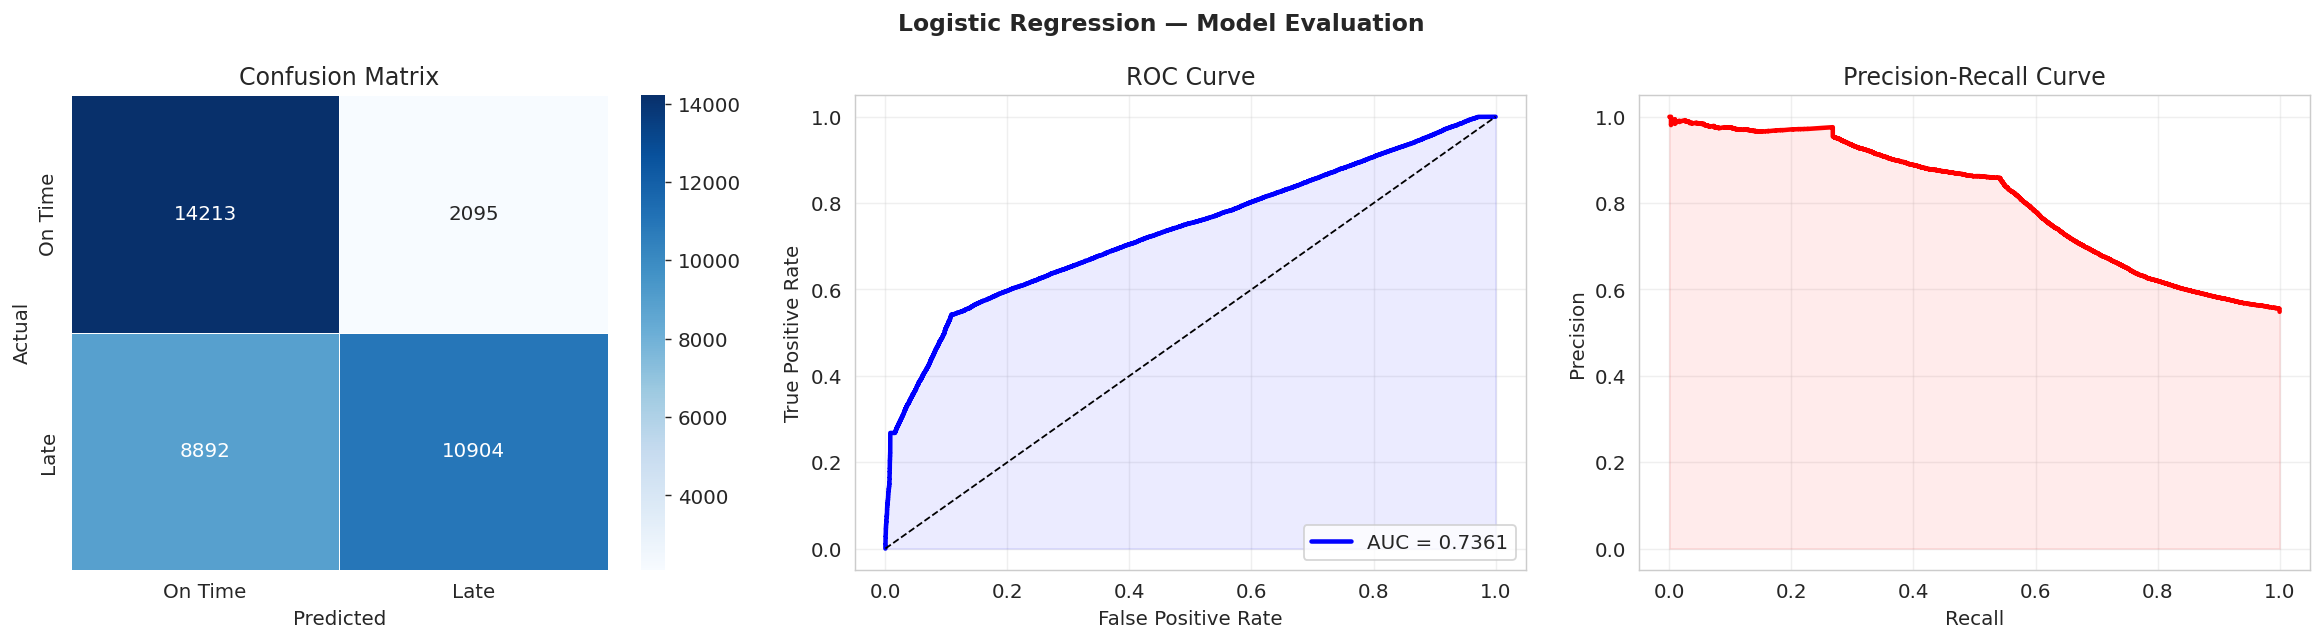

✅ Logistic Regression training complete!


In [ ]:
print("🔄 Training Logistic Regression (Baseline)...\n")

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train_res)

lr_metrics, lr_pred, lr_proba = evaluate_model(
    lr_model, X_test_scaled, y_test, "Logistic Regression"
)

print("✅ Logistic Regression training complete!")

**Model 2: Random Forest**

🌲 Training Random Forest Classifier...

  OOB Score: 0.7397

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Random Forest — Evaluation Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy    : 0.7170  ★★★
  Precision   : 0.8797  ★★★★
  Recall      : 0.5606  ★★
  F1 Score    : 0.6848  ★★★
  ROC-AUC     : 0.7988  ★★★

              precision    recall  f1-score   support

     On Time       0.63      0.91      0.74     16308
        Late       0.88      0.56      0.68     19796

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.71     36104
weighted avg       0.77      0.72      0.71     36104



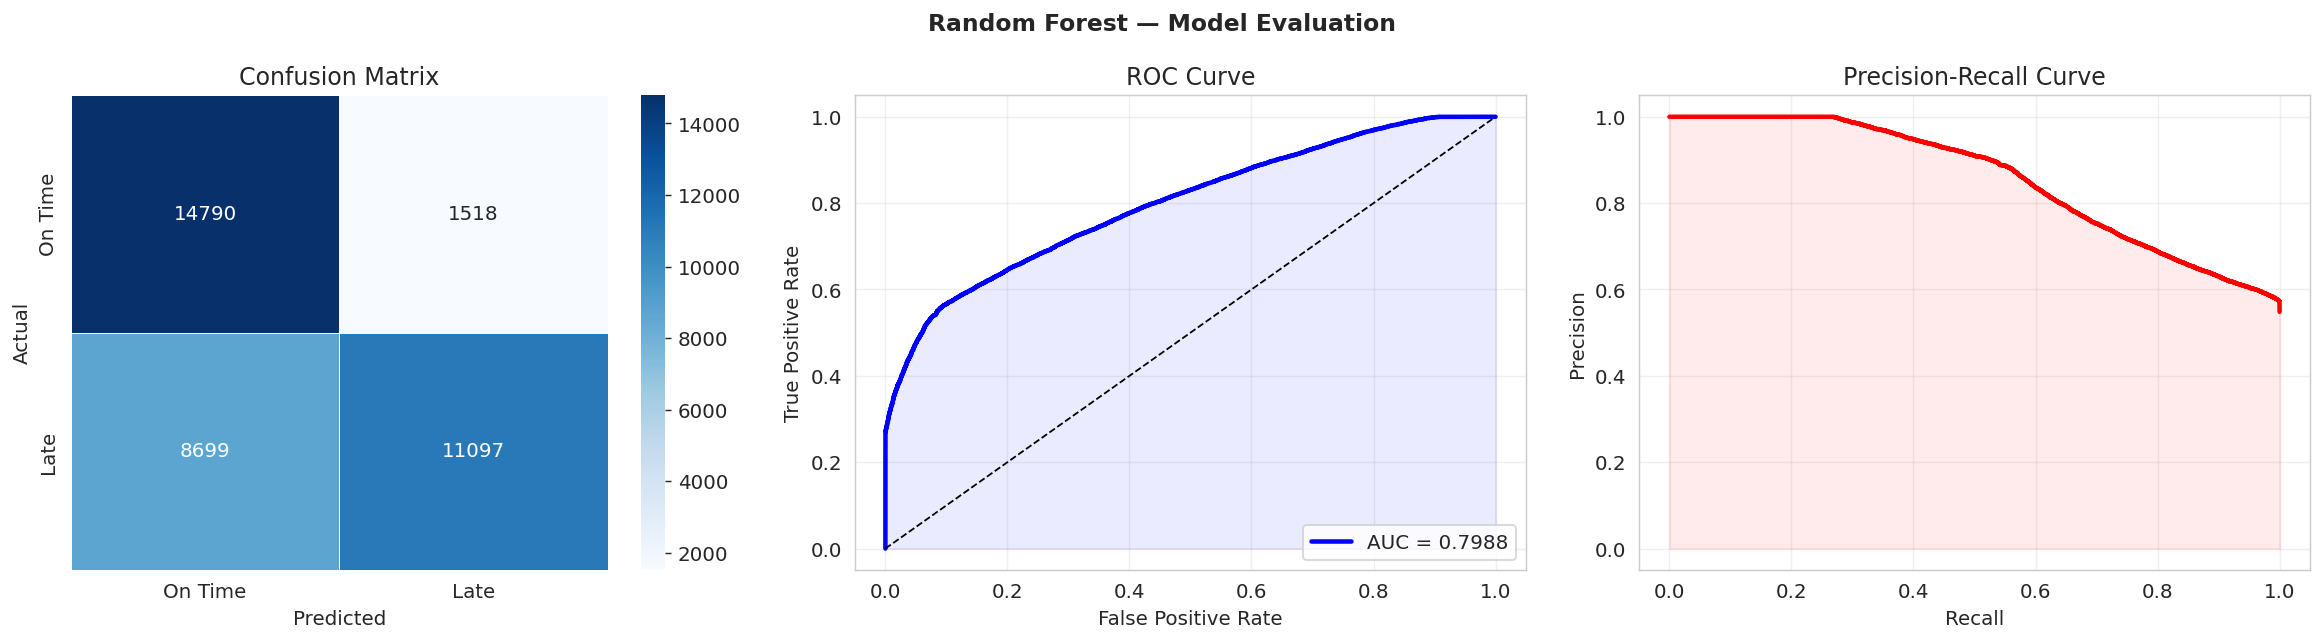

✅ Random Forest training complete!


In [ ]:
print("🌲 Training Random Forest Classifier...\n")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    oob_score=True
)
rf_model.fit(X_train_res, y_train_res)

print(f"  OOB Score: {rf_model.oob_score_:.4f}")

rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model, X_test, y_test, "Random Forest"
)

print("✅ Random Forest training complete!")

**Model 3: XGBoost**

⚡ Training XGBoost Classifier...

  scale_pos_weight: 1.000
[0]	validation_0-logloss:0.67164
[50]	validation_0-logloss:0.51381
[100]	validation_0-logloss:0.50861
[150]	validation_0-logloss:0.50418
[200]	validation_0-logloss:0.50145
[250]	validation_0-logloss:0.49888
[299]	validation_0-logloss:0.49575

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 XGBoost — Evaluation Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy    : 0.7263  ★★★
  Precision   : 0.8592  ★★★★
  Recall      : 0.5989  ★★
  F1 Score    : 0.7058  ★★★
  ROC-AUC     : 0.8146  ★★★★

              precision    recall  f1-score   support

     On Time       0.64      0.88      0.74     16308
        Late       0.86      0.60      0.71     19796

    accuracy                           0.73     36104
   macro avg       0.75      0.74      0.72     36104
weighted avg       0.76      0.73      0.72     36104



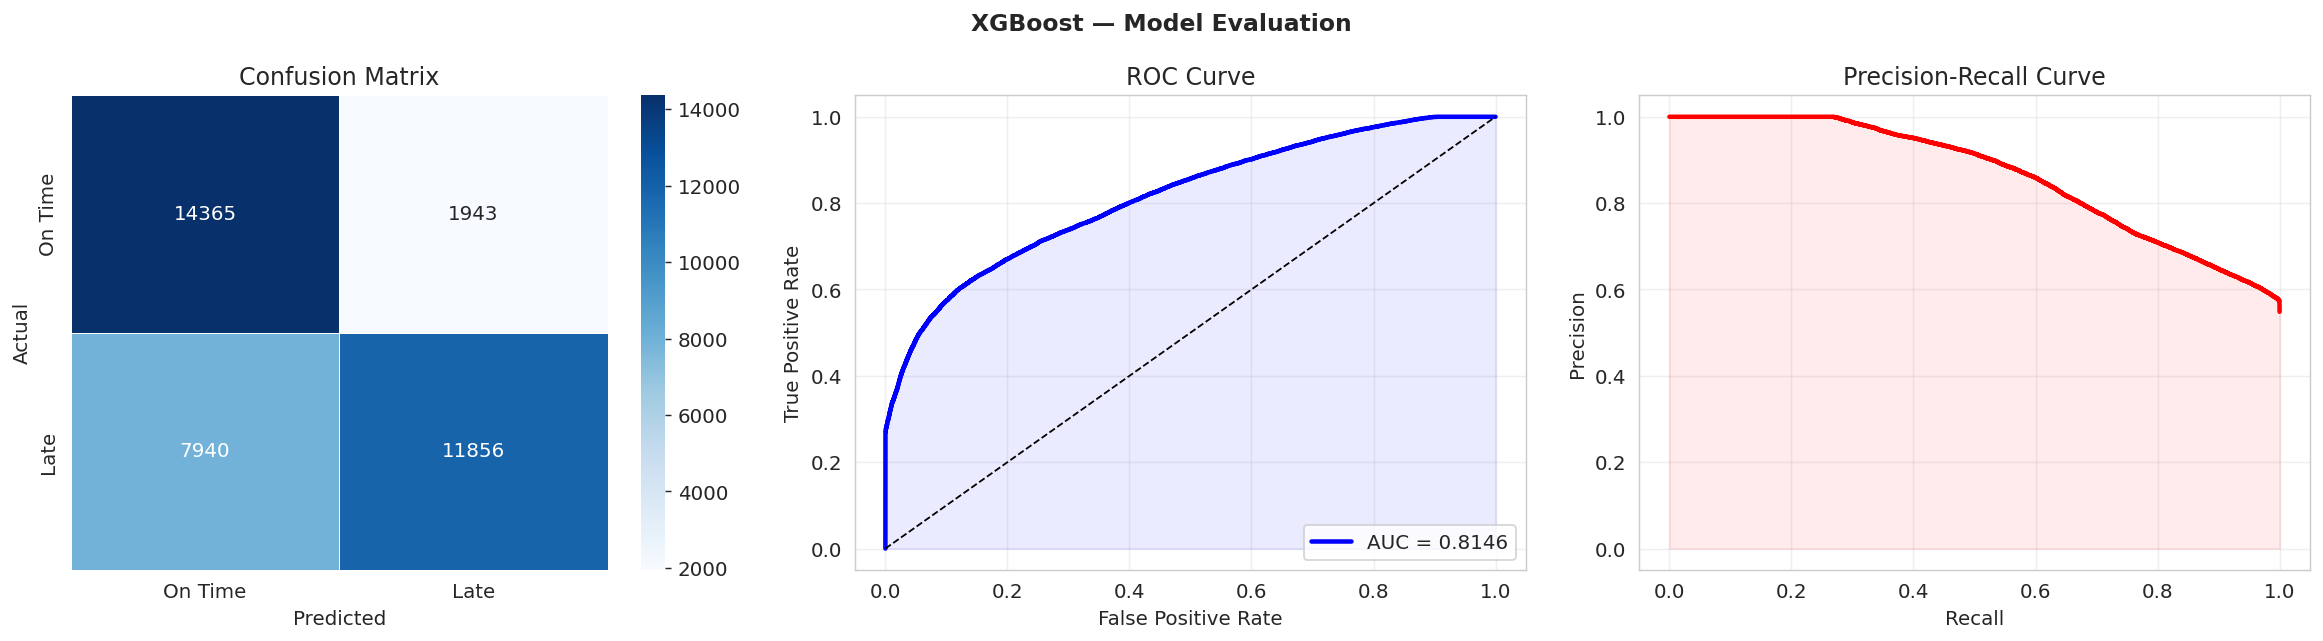

✅ XGBoost training complete!


In [ ]:
print("⚡ Training XGBoost Classifier...\n")

# Compute class weight for imbalance handling
scale_pw = (y_train_res == 0).sum() / (y_train_res == 1).sum()
print(f"  scale_pos_weight: {scale_pw:.3f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pw,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_test, y_test, "XGBoost"
)

print("✅ XGBoost training complete!")

**Cross-Validation Comparison**

🔁 Running 5-Fold Stratified Cross-Validation...

  Logistic Regression:
    F1  = 0.6628 ± 0.0037
    AUC = 0.7553 ± 0.0033

  Random Forest:
    F1  = 0.6816 ± 0.0032
    AUC = 0.8268 ± 0.0024

  XGBoost:
    F1  = 0.7018 ± 0.0035
    AUC = 0.8392 ± 0.0024



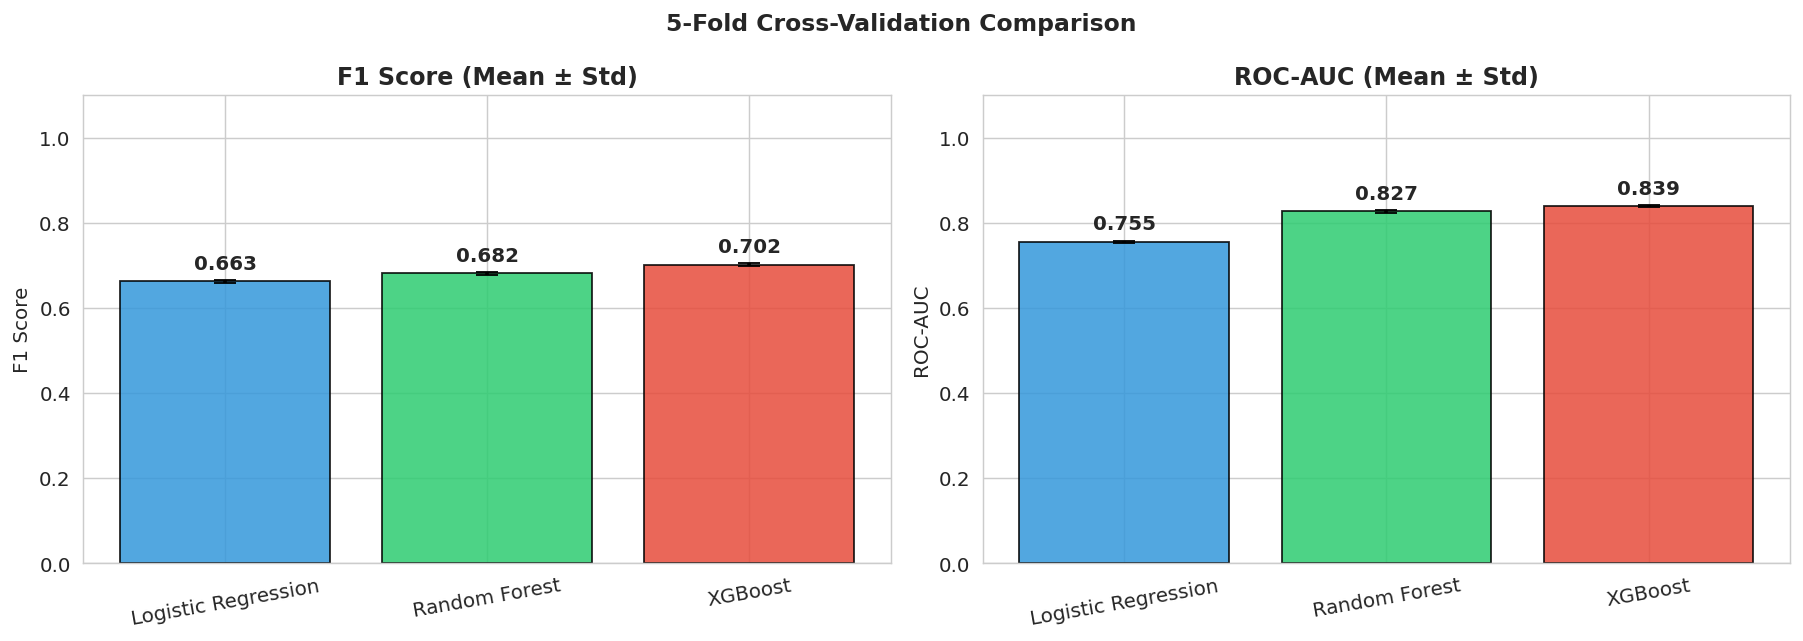

In [ ]:
print("🔁 Running 5-Fold Stratified Cross-Validation...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_configs = {
    'Logistic Regression': (lr_model,  X_train_scaled),
    'Random Forest'      : (rf_model,  X_train_res),
    'XGBoost'            : (xgb_model, X_train_res),
}

cv_results = {}
for name, (model, X_cv) in cv_configs.items():
    f1_cv  = cross_val_score(model, X_cv, y_train_res,
                             cv=cv, scoring='f1', n_jobs=-1)
    auc_cv = cross_val_score(model, X_cv, y_train_res,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {
        'F1 Mean' : f1_cv.mean(), 'F1 Std' : f1_cv.std(),
        'AUC Mean': auc_cv.mean(),'AUC Std': auc_cv.std()
    }
    print(f"  {name}:")
    print(f"    F1  = {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")
    print(f"    AUC = {auc_cv.mean():.4f} ± {auc_cv.std():.4f}\n")

# Plot comparison
cv_df = pd.DataFrame(cv_results).T.reset_index()
cv_df.columns = ['Model', 'F1 Mean', 'F1 Std', 'AUC Mean', 'AUC Std']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Cross-Validation Comparison', fontsize=13, fontweight='bold')
colors_cv = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric_m, metric_s, title in [
    (axes[0], 'F1 Mean', 'F1 Std', 'F1 Score'),
    (axes[1], 'AUC Mean', 'AUC Std', 'ROC-AUC')
]:
    bars = ax.bar(cv_df['Model'], cv_df[metric_m],
                  yerr=cv_df[metric_s], color=colors_cv,
                  edgecolor='black', alpha=0.85, capsize=6,
                  error_kw={'linewidth': 2})
    ax.set_title(f'{title} (Mean ± Std)', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=10)
    for bar, v, s in zip(bars, cv_df[metric_m], cv_df[metric_s]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + s + 0.025, f'{v:.3f}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

**Model Comparison & Best Model Selection**

  FINAL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.6957     0.8388  0.5508    0.6650   0.7361
Random Forest          0.7170     0.8797  0.5606    0.6848   0.7988
XGBoost                0.7263     0.8592  0.5989    0.7058   0.8146

🏆 Best Model : XGBoost
   ROC-AUC   : 0.8146
   F1 Score  : 0.7058
   Recall    : 0.5989


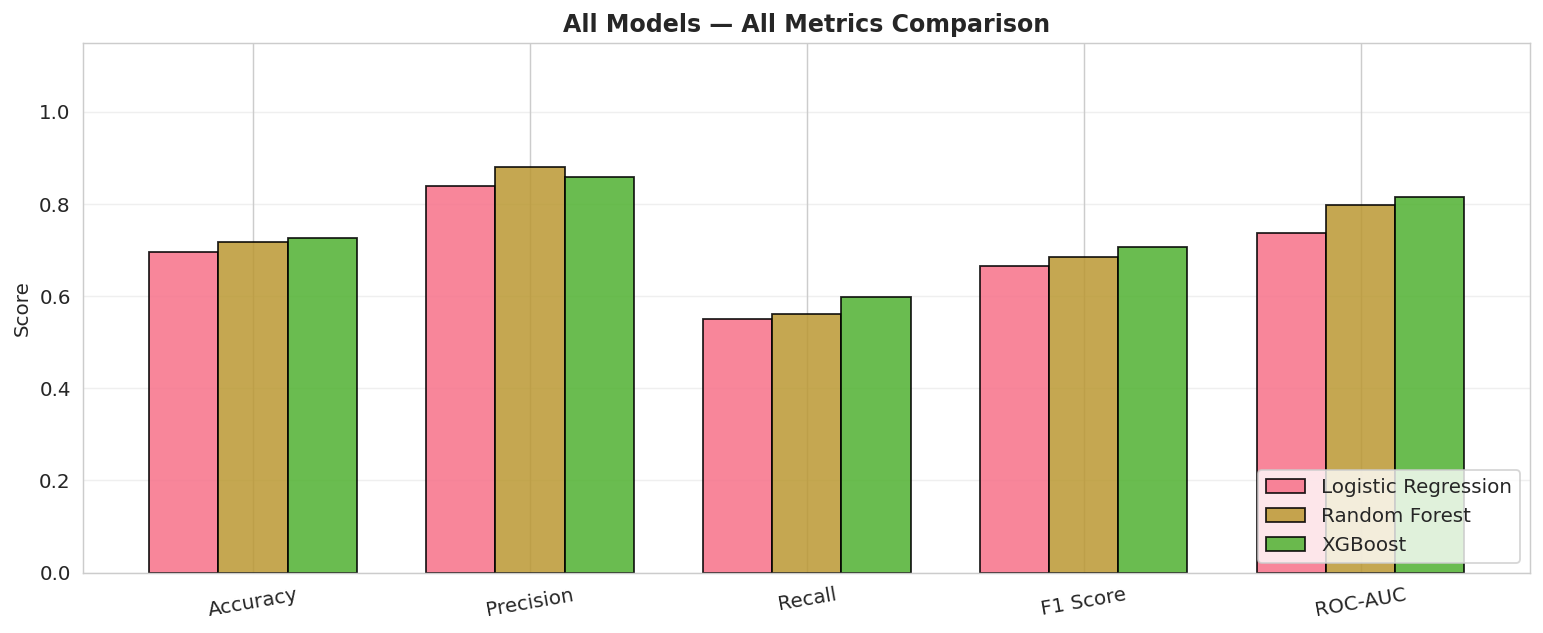

In [ ]:
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest'      : rf_metrics,
    'XGBoost'            : xgb_metrics
}).T.round(4)

print("=" * 65)
print("  FINAL MODEL COMPARISON")
print("=" * 65)
print(comparison.to_string())

# Select best by ROC-AUC
best_name  = comparison['ROC-AUC'].idxmax()
best_model = {'Logistic Regression': lr_model,
              'Random Forest': rf_model,
              'XGBoost': xgb_model}[best_name]
best_proba = {'Logistic Regression': lr_proba,
              'Random Forest': rf_proba,
              'XGBoost': xgb_proba}[best_name]

print(f"\n🏆 Best Model : {best_name}")
print(f"   ROC-AUC   : {comparison.loc[best_name,'ROC-AUC']:.4f}")
print(f"   F1 Score  : {comparison.loc[best_name,'F1 Score']:.4f}")
print(f"   Recall    : {comparison.loc[best_name,'Recall']:.4f}")

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison.columns))
width = 0.25
model_names = comparison.index.tolist()
for i, mname in enumerate(model_names):
    ax.bar(x + i * width, comparison.loc[mname].values,
           width, label=mname, alpha=0.85, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(comparison.columns, rotation=10)
ax.set_title('All Models — All Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Risk Probability & Classification**

🎯 Assigning risk probabilities & categories to all orders...

📊 Risk Category Distribution:
  Risk Category        Count        %
  ──────────────────────────────────
  Low Risk            73,712    40.8%
  High Risk           59,016    32.7%
  Medium Risk         47,791    26.5%


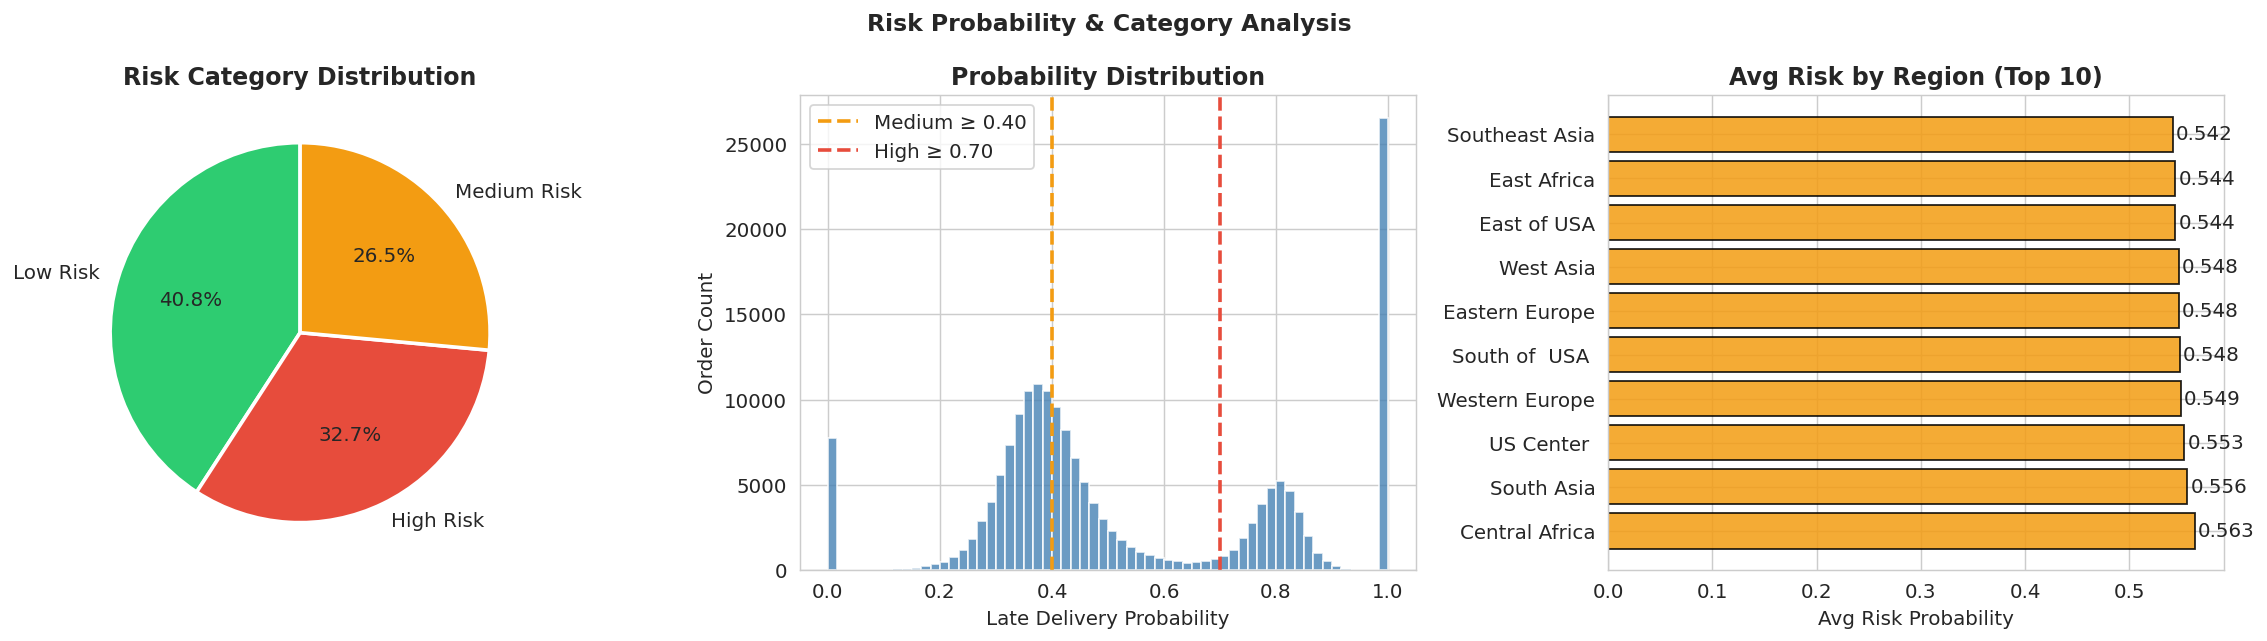

In [ ]:
print("🎯 Assigning risk probabilities & categories to all orders...\n")

# Predict probabilities for the full dataset
all_proba = best_model.predict_proba(X_encoded)[:, 1]

# Risk classification function
def classify_risk(p, high_thresh=0.70, medium_thresh=0.40):
    if p >= high_thresh:
        return 'High Risk'
    elif p >= medium_thresh:
        return 'Medium Risk'
    return 'Low Risk'

# Attach to results dataframe
df_results = df_clean.copy()
df_results['Late_Delivery_Probability'] = all_proba
df_results['Risk_Category'] = df_results['Late_Delivery_Probability'].apply(classify_risk)

# Summary stats
risk_summary = df_results['Risk_Category'].value_counts()
print("📊 Risk Category Distribution:")
print(f"  {'Risk Category':<16}  {'Count':>8}   {'%':>6}")
print("  " + "─" * 34)
for cat, cnt in risk_summary.items():
    pct = cnt / len(df_results) * 100
    print(f"  {cat:<16}  {cnt:>8,}   {pct:>5.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Risk Probability & Category Analysis', fontsize=13, fontweight='bold')

risk_colors = {'High Risk': '#e74c3c', 'Medium Risk': '#f39c12', 'Low Risk': '#2ecc71'}

# Pie
axes[0].pie(risk_summary,
            labels=risk_summary.index,
            colors=[risk_colors[r] for r in risk_summary.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Risk Category Distribution', fontweight='bold')

# Histogram
axes[1].hist(df_results['Late_Delivery_Probability'],
             bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0.40, color='#f39c12', linestyle='--',
                linewidth=2, label='Medium ≥ 0.40')
axes[1].axvline(x=0.70, color='#e74c3c', linestyle='--',
                linewidth=2, label='High ≥ 0.70')
axes[1].set_xlabel('Late Delivery Probability')
axes[1].set_ylabel('Order Count')
axes[1].set_title('Probability Distribution', fontweight='bold')
axes[1].legend()

# Risk by Region (top 10)
region_risk_avg = (df_results.groupby('Order Region')['Late_Delivery_Probability']
                   .mean().sort_values(ascending=False).head(10))
colors_r = [risk_colors['High Risk'] if v >= 0.70
            else risk_colors['Medium Risk'] if v >= 0.40
            else risk_colors['Low Risk']
            for v in region_risk_avg.values]
axes[2].barh(region_risk_avg.index, region_risk_avg.values,
             color=colors_r, edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Risk by Region (Top 10)', fontweight='bold')
axes[2].set_xlabel('Avg Risk Probability')
for i, v in enumerate(region_risk_avg.values):
    axes[2].text(v + 0.003, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('risk_classification.png', dpi=150, bbox_inches='tight')
plt.show()

**SHAP Explainability**

🔍 Computing SHAP values — this may take 1-2 minutes...



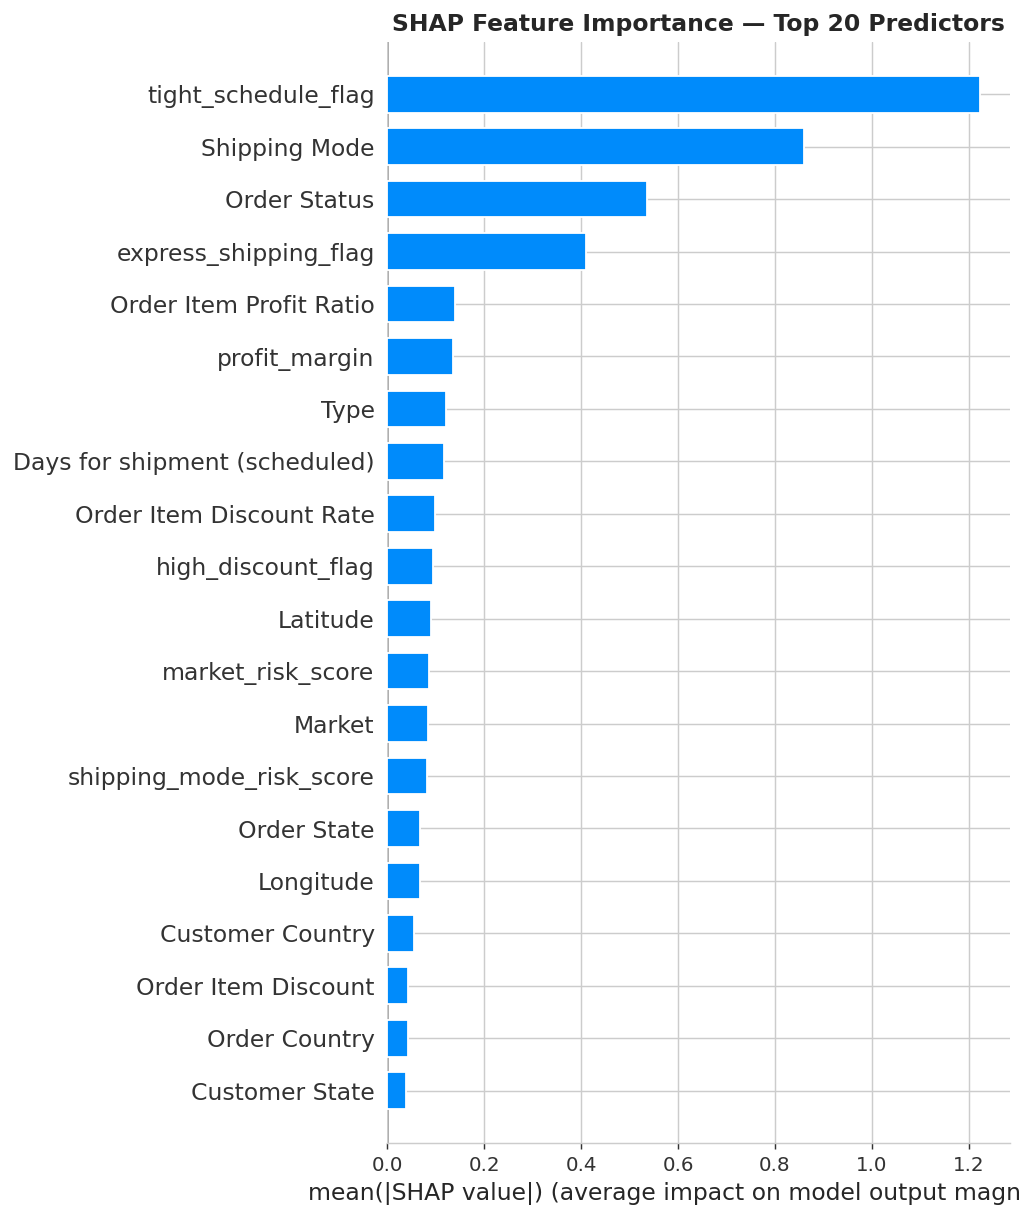

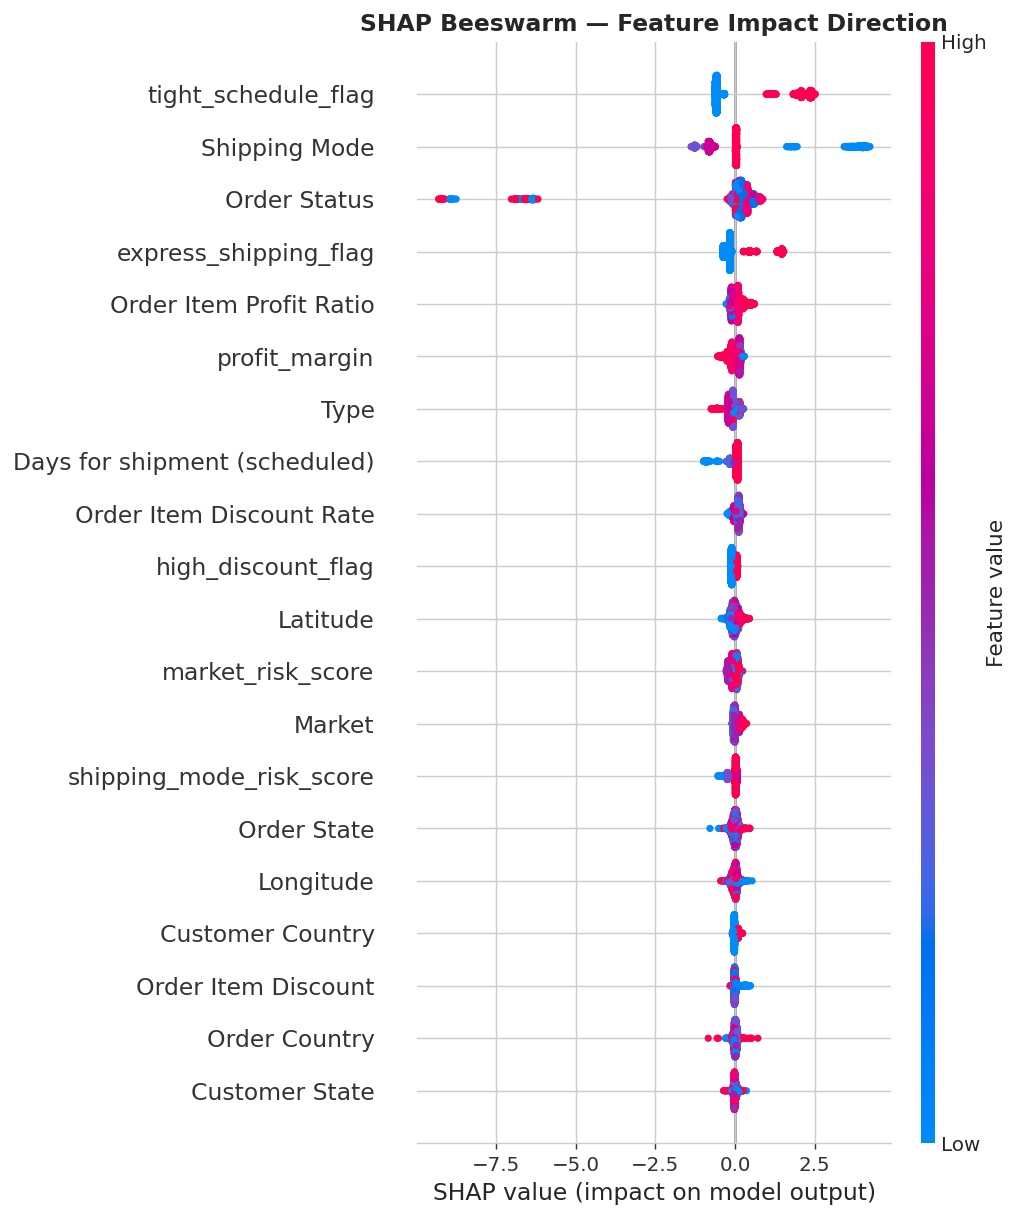

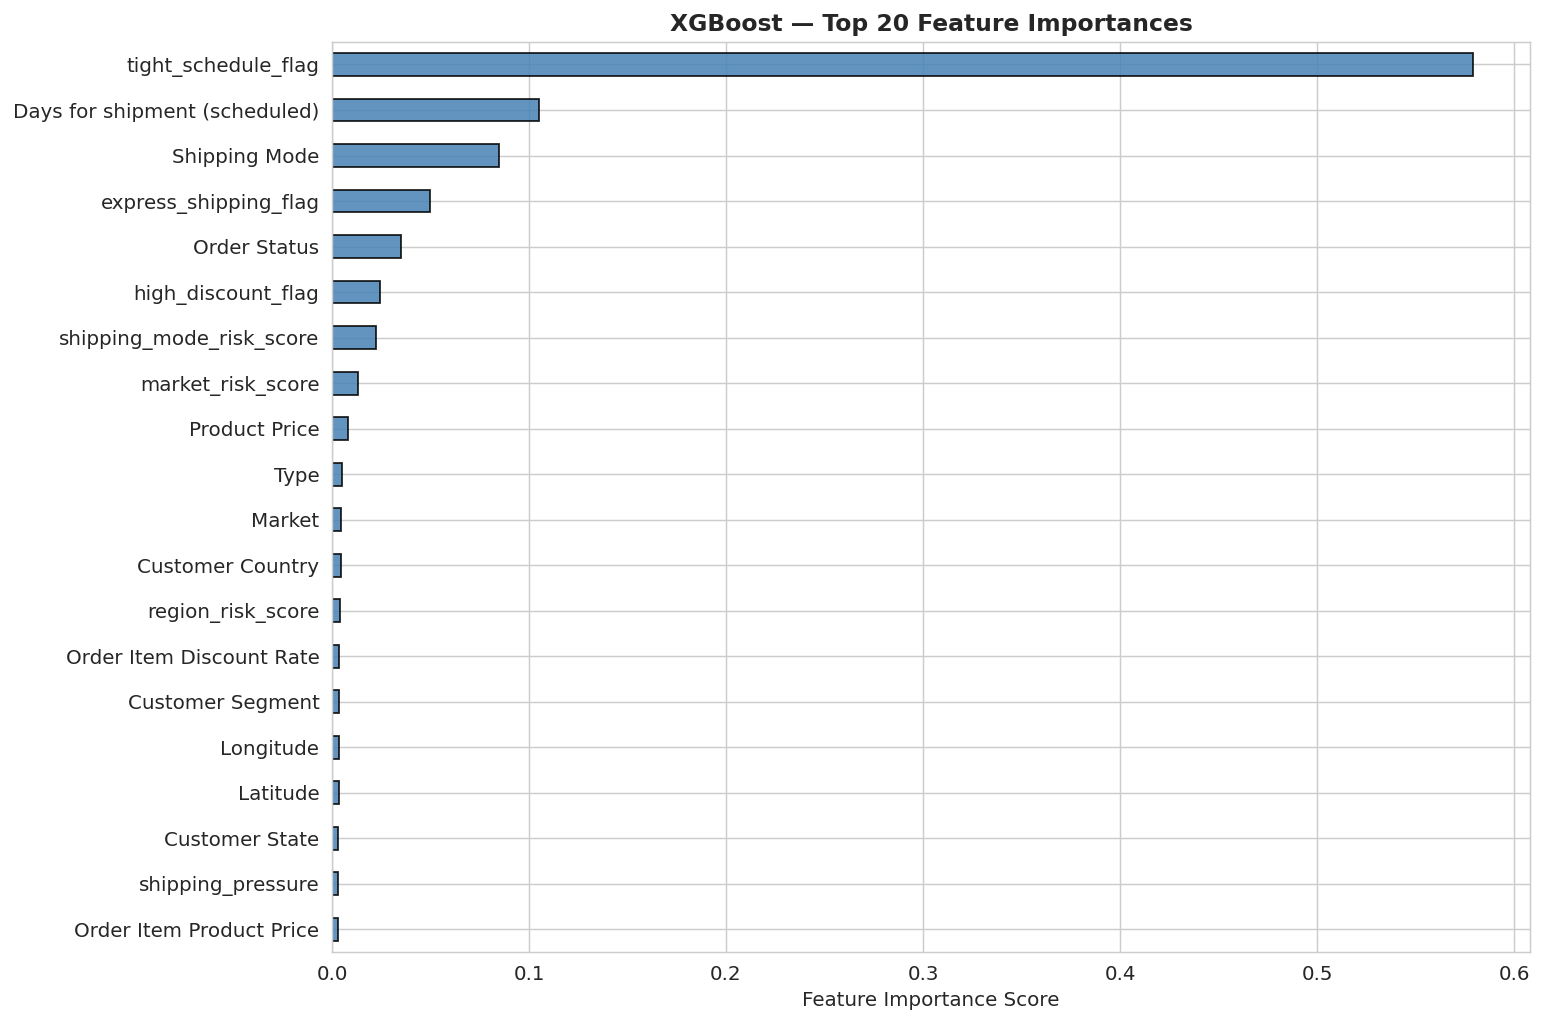

Top 10 Most Important Features:
tight_schedule_flag              0.579188
Days for shipment (scheduled)    0.105000
Shipping Mode                    0.084813
express_shipping_flag            0.049556
Order Status                     0.035117
high_discount_flag               0.024358
shipping_mode_risk_score         0.022345
market_risk_score                0.013268
Product Price                    0.007890
Type                             0.005169

✅ SHAP explainability analysis complete!


In [ ]:
print("🔍 Computing SHAP values — this may take 1-2 minutes...\n")

# Use a representative sample (faster, still meaningful)
SAMPLE_N = min(3000, len(X_test))
X_shap   = X_test.iloc[:SAMPLE_N]

# Tree explainer works for both RF and XGBoost
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# For binary classification, use class-1 SHAP values
if isinstance(shap_values, list):
    sv_plot = shap_values[1]
else:
    sv_plot = shap_values

feature_names = ALL_FEATURES

# ── Plot 1: Feature Importance (bar) ────────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(sv_plot, X_shap, feature_names=feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — Top 20 Predictors',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Beeswarm (direction + magnitude) ────────────────────
plt.figure(figsize=(12, 10))
shap.summary_plot(sv_plot, X_shap, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Model's own feature importances ──────────────────────
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_,
                         index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    feat_imp.head(20).sort_values().plot(
        kind='barh', color='steelblue', edgecolor='black', alpha=0.85
    )
    plt.title(f'{best_name} — Top 20 Feature Importances',
              fontsize=13, fontweight='bold')
    plt.xlabel('Feature Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 10 Most Important Features:")
    print(feat_imp.head(10).to_string())

print("\n✅ SHAP explainability analysis complete!")

**Save All Models & Artifacts**

In [ ]:
# Create directories
os.makedirs('/content/models',  exist_ok=True)
os.makedirs('/content/outputs', exist_ok=True)

# Save all models
joblib.dump(lr_model,        '/content/models/logistic_regression.pkl')
joblib.dump(rf_model,        '/content/models/random_forest.pkl')
joblib.dump(xgb_model,       '/content/models/xgboost_model.pkl')
joblib.dump(best_model,      '/content/models/best_model.pkl')
joblib.dump(scaler,          '/content/models/scaler.pkl')
joblib.dump(label_encoders,  '/content/models/label_encoders.pkl')

# Save risk-scored dataset
df_results.to_csv('/content/outputs/APL_Logistics_with_risk_scores.csv', index=False)

# Save feature metadata for Streamlit
feature_info = {
    'all_features'         : ALL_FEATURES,
    'categorical_features' : CATEGORICAL_FEATURES,
    'numerical_features'   : NUMERICAL_FEATURES,
    'feature_mappings'     : feature_mappings,
    'best_model'           : best_name,
    'risk_thresholds'      : {'high': 0.70, 'medium': 0.40}
}
with open('/content/models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2, default=str)

# Save model comparison for reference
comparison.to_csv('/content/outputs/model_comparison.csv')

print("✅ All artifacts saved!\n")
print("📁 /content/models/")
for f in sorted(os.listdir('/content/models')):
    size = os.path.getsize(f'/content/models/{f}')
    print(f"   • {f:35s} {size/1024:.1f} KB")
print("\n📁 /content/outputs/")
for f in sorted(os.listdir('/content/outputs')):
    size = os.path.getsize(f'/content/outputs/{f}')
    print(f"   • {f:45s} {size/1024:.1f} KB")

✅ All artifacts saved!

📁 /content/models/
   • best_model.pkl                      979.8 KB
   • feature_info.json                   35.8 KB
   • label_encoders.pkl                  19.3 KB
   • logistic_regression.pkl             1.1 KB
   • random_forest.pkl                   48887.4 KB
   • scaler.pkl                          2.3 KB
   • xgboost_model.pkl                   979.8 KB

📁 /content/outputs/
   • APL_Logistics_with_risk_scores.csv            64383.9 KB
   • model_comparison.csv                          0.2 KB


**Write Streamlit Application**

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────
# PAGE CONFIG
# ──────────────────────────────────────────
st.set_page_config(
    page_title="APL Logistics — Risk Intelligence",
    page_icon="🚚",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ──────────────────────────────────────────
# CUSTOM CSS
# ──────────────────────────────────────────
st.markdown("""
<style>
    .main-header {
        background: linear-gradient(135deg, #0f3460 0%, #16213e 50%, #1a1a2e 100%);
        padding: 2rem 2.5rem;
        border-radius: 14px;
        text-align: center;
        margin-bottom: 1.5rem;
        color: white;
    }
    .main-header h1 { font-size: 2.1rem; margin: 0; }
    .main-header p  { font-size: 1rem; opacity: 0.85; margin-top: 0.4rem; }
    .risk-badge-high   { background:#ffeaea; color:#c0392b;
                         border:1px solid #e74c3c; border-radius:6px;
                         padding:3px 10px; font-weight:bold; }
    .risk-badge-medium { background:#fff7e0; color:#856404;
                         border:1px solid #f39c12; border-radius:6px;
                         padding:3px 10px; font-weight:bold; }
    .risk-badge-low    { background:#eafaf1; color:#196f3d;
                         border:1px solid #2ecc71; border-radius:6px;
                         padding:3px 10px; font-weight:bold; }
    div[data-testid="metric-container"] {
        background:#f8f9fa; border:1px solid #dee2e6;
        padding:12px; border-radius:10px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.06);
    }
</style>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────
# LOAD MODELS & DATA
# ──────────────────────────────────────────
@st.cache_resource
def load_models():
    base = "/content/models"
    return {
        "best_model"     : joblib.load(f"{base}/best_model.pkl"),
        "scaler"         : joblib.load(f"{base}/scaler.pkl"),
        "label_encoders" : joblib.load(f"{base}/label_encoders.pkl"),
        "feature_info"   : json.load(open(f"{base}/feature_info.json"))
    }

@st.cache_data
def load_data():
    return pd.read_csv(
        "/content/outputs/APL_Logistics_with_risk_scores.csv",
        encoding="latin1"
    )

models = load_models()
df     = load_data()

# ──────────────────────────────────────────
# SIDEBAR CONTROLS
# ──────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🎛️ Control Panel")
    st.markdown("---")

    sel_mode = st.selectbox(
        "🚢 Shipping Mode",
        ["All"] + sorted(df["Shipping Mode"].unique().tolist())
    )
    sel_market = st.selectbox(
        "🌍 Market / Region",
        ["All"] + sorted(df["Market"].unique().tolist())
    )
    sel_segment = st.selectbox(
        "👥 Customer Segment",
        ["All"] + sorted(df["Customer Segment"].unique().tolist())
    )

    st.markdown("### ⚠️ Risk Threshold")
    risk_thresh = st.slider(
        "Flag orders above this probability as High Risk",
        min_value=0.0, max_value=1.0, value=0.70, step=0.05
    )

    st.markdown("---")
    st.info("💡 Filters update all four dashboard tabs in real time.")

# ──────────────────────────────────────────
# APPLY FILTERS
# ──────────────────────────────────────────
dff = df.copy()
if sel_mode    != "All": dff = dff[dff["Shipping Mode"]     == sel_mode]
if sel_market  != "All": dff = dff[dff["Market"]            == sel_market]
if sel_segment != "All": dff = dff[dff["Customer Segment"]  == sel_segment]

# ──────────────────────────────────────────
# HEADER
# ──────────────────────────────────────────
st.markdown("""
<div class="main-header">
  <h1>🚚 APL Logistics — Delivery Risk Intelligence</h1>
  <p>ML-Powered Late Delivery Risk Prediction | Supply Chain Analytics</p>
</div>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────
# TABS
# ──────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Delay Risk Overview",
    "🔍 Order-Level Prediction",
    "🗺️ Region & Mode Analysis",
    "⚡ Operations Action Panel"
])


# ════════════════════════════════════════════
# TAB 1 — DELAY RISK OVERVIEW
# ════════════════════════════════════════════
with tab1:
    st.subheader("📊 Delay Risk Overview")

    n      = len(dff)
    n_high = (dff["Risk_Category"] == "High Risk").sum()
    n_med  = (dff["Risk_Category"] == "Medium Risk").sum()
    n_low  = (dff["Risk_Category"] == "Low Risk").sum()
    avg_p  = dff["Late_Delivery_Probability"].mean()
    act    = dff["Late_delivery_risk"].mean()

    c1,c2,c3,c4,c5 = st.columns(5)
    c1.metric("📦 Orders",       f"{n:,}")
    c2.metric("🔴 High Risk",    f"{n_high:,}", f"{n_high/n:.1%}")
    c3.metric("🟡 Medium Risk",  f"{n_med:,}",  f"{n_med/n:.1%}")
    c4.metric("🟢 Low Risk",     f"{n_low:,}",  f"{n_low/n:.1%}")
    c5.metric("📈 Avg Risk",     f"{avg_p:.3f}", f"Actual: {act:.1%}")
    st.markdown("---")

    col_a, col_b = st.columns(2)

    with col_a:
        rc = dff["Risk_Category"].value_counts()
        fig = go.Figure(go.Pie(
            labels=rc.index, values=rc.values, hole=0.42,
            marker_colors=["#e74c3c","#f39c12","#2ecc71"],
            textinfo="label+percent"
        ))
        fig.update_layout(title="Risk Category Distribution", height=360,
                          legend=dict(orientation="h", y=-0.15))
        st.plotly_chart(fig, use_container_width=True)

    with col_b:
        fig = px.histogram(
            dff, x="Late_Delivery_Probability", nbins=60,
            title="Risk Probability Distribution",
            color_discrete_sequence=["#3498db"]
        )
        fig.add_vline(x=0.40, line_dash="dash", line_color="orange",
                      annotation_text="Medium ≥0.40")
        fig.add_vline(x=risk_thresh, line_dash="dash", line_color="red",
                      annotation_text=f"High ≥{risk_thresh}")
        fig.update_layout(height=360)
        st.plotly_chart(fig, use_container_width=True)

    col_c, col_d = st.columns(2)
    with col_c:
        mr = dff.groupby("Shipping Mode")["Late_Delivery_Probability"].mean().reset_index()
        fig = px.bar(mr, x="Shipping Mode", y="Late_Delivery_Probability",
                     color="Late_Delivery_Probability",
                     color_continuous_scale="RdYlGn_r",
                     title="Average Risk by Shipping Mode")
        fig.update_layout(height=320)
        st.plotly_chart(fig, use_container_width=True)

    with col_d:
        sr = dff.groupby("Customer Segment")["Late_Delivery_Probability"].mean().reset_index()
        fig = px.bar(sr, x="Customer Segment", y="Late_Delivery_Probability",
                     color="Late_Delivery_Probability",
                     color_continuous_scale="RdYlGn_r",
                     title="Average Risk by Customer Segment")
        fig.update_layout(height=320)
        st.plotly_chart(fig, use_container_width=True)


# ════════════════════════════════════════════
# TAB 2 — ORDER-LEVEL PREDICTION
# ════════════════════════════════════════════
with tab2:
    st.subheader("🔍 Order-Level Risk Prediction")
    st.markdown("Enter new order details to receive an instant delivery risk score.")

    c1, c2, c3 = st.columns(3)
    with c1:
        i_mode   = st.selectbox("Shipping Mode",
            ["Standard Class","Second Class","First Class","Same Day"])
        i_sched  = st.slider("Scheduled Days", 1, 7, 4)
        i_qty    = st.slider("Order Quantity", 1, 10, 2)
        i_market = st.selectbox("Market", df["Market"].unique().tolist())
    with c2:
        i_seg    = st.selectbox("Customer Segment",
            ["Consumer","Corporate","Home Office"])
        i_price  = st.number_input("Product Price ($)", 10.0, 2000.0, 99.99)
        i_disc   = st.slider("Discount Rate", 0.0, 0.5, 0.10, step=0.01)
        i_status = st.selectbox("Order Status",
            ["COMPLETE","PENDING_PAYMENT","PROCESSING","PENDING","ON_HOLD"])
    with c3:
        i_dept   = st.selectbox("Department", df["Department Name"].unique().tolist())
        i_cat    = st.selectbox("Category",   df["Category Name"].unique().tolist())
        i_region = st.selectbox("Order Region", df["Order Region"].unique().tolist())
        i_ben    = st.number_input("Benefit per Order ($)", -100.0, 500.0, 50.0)

    if st.button("🔮 Predict Risk", type="primary", use_container_width=True):
        try:
            fi   = models["feature_info"]
            af   = fi["all_features"]
            les  = models["label_encoders"]
            row  = {f: (df[f].median() if f in df.columns else 0) for f in af}

            row.update({
                "Days for shipment (scheduled)": i_sched,
                "Shipping Mode"  : i_mode,  "Market"          : i_market,
                "Customer Segment": i_seg,  "Order Item Quantity": i_qty,
                "Order Item Product Price": i_price,
                "Order Item Discount Rate": i_disc,
                "Order Status"   : i_status,"Department Name" : i_dept,
                "Category Name"  : i_cat,  "Order Region"    : i_region,
                "Benefit per order": i_ben,
            })

            # Feature engineering
            row["shipping_pressure"]      = i_qty / (i_sched + 1)
            row["tight_schedule_flag"]    = int(i_sched <= 2)
            row["high_discount_flag"]     = int(i_disc > 0.15)
            row["order_complexity"]       = i_price * i_qty
            row["express_shipping_flag"]  = int(i_mode in ["First Class","Same Day"])
            row["profit_margin"]          = i_ben / (row.get("Sales per customer",200)+1)
            row["high_value_order"]       = int(i_price * i_qty > df["Order Item Total"].quantile(0.75))
            row["shipping_mode_risk_score"] = {"Standard Class":3,"Second Class":2,
                                               "First Class":1,"Same Day":0}.get(i_mode,2)
            row["region_risk_score"]  = df.groupby("Order Region")["Late_delivery_risk"].mean().get(i_region,0.5)
            row["market_risk_score"]  = df.groupby("Market")["Late_delivery_risk"].mean().get(i_market,0.5)

            input_df = pd.DataFrame([row])[af]
            for col in fi["categorical_features"]:
                if col in input_df.columns and col in les:
                    le  = les[col]
                    val = str(input_df[col].values[0])
                    input_df[col] = le.transform([val])[0] if val in le.classes_ else 0

            prob = models["best_model"].predict_proba(input_df)[0][1]
            cat  = ("High Risk" if prob >= risk_thresh
                    else "Medium Risk" if prob >= 0.40 else "Low Risk")
            color = {"High Risk":"#e74c3c","Medium Risk":"#f39c12","Low Risk":"#2ecc71"}[cat]

            st.markdown("---")
            _, mid, _ = st.columns([1,2,1])
            with mid:
                st.markdown(f"""
                <div style="text-align:center;padding:2rem;background:#f8f9fa;
                            border-radius:14px;border:3px solid {color};">
                  <h2 style="color:{color};margin:0;">
                    {"🔴" if cat=="High Risk" else "🟡" if cat=="Medium Risk" else "🟢"} {cat}
                  </h2>
                  <div style="font-size:3.5rem;color:{color};font-weight:800;margin:0.5rem 0;">
                    {prob:.1%}
                  </div>
                  <p style="color:#666;">Late Delivery Probability</p>
                </div>""", unsafe_allow_html=True)

            st.markdown("### 🎯 Key Risk Drivers")
            rm = {"Standard Class":3,"Second Class":2,"First Class":1,"Same Day":0}
            factors = {
                "Standard shipping mode"  : rm.get(i_mode,2)/3,
                "Tight schedule (≤2 days)": row["tight_schedule_flag"],
                "High discount rate"      : row["high_discount_flag"],
                "Shipping pressure"       : min(row["shipping_pressure"]/5, 1.0),
                "Regional delay history"  : row["region_risk_score"],
                "Market delay history"    : row["market_risk_score"],
                "Non-express shipping"    : 1 - row["express_shipping_flag"],
            }
            fd = pd.DataFrame(list(factors.items()),
                              columns=["Factor","Risk Score"]).sort_values("Risk Score")
            fig = px.bar(fd, x="Risk Score", y="Factor", orientation="h",
                         color="Risk Score", color_continuous_scale="RdYlGn_r",
                         range_x=[0,1], title="Contributing Risk Factors")
            fig.update_layout(height=320)
            st.plotly_chart(fig, use_container_width=True)

        except Exception as e:
            st.error(f"Prediction error: {e}")


# ════════════════════════════════════════════
# TAB 3 — REGION & MODE ANALYSIS
# ════════════════════════════════════════════
with tab3:
    st.subheader("🗺️ Region & Mode Risk Analysis")
    c1, c2 = st.columns(2)

    with c1:
        rr = (dff.groupby("Order Region")
              .agg(Avg_Risk=("Late_Delivery_Probability","mean"),
                   Orders=("Late_delivery_risk","count"))
              .reset_index()
              .sort_values("Avg_Risk", ascending=False))
        fig = px.bar(rr, x="Avg_Risk", y="Order Region", orientation="h",
                     color="Avg_Risk", color_continuous_scale="RdYlGn_r",
                     text=rr["Avg_Risk"].map("{:.1%}".format),
                     title="Risk Heatmap by Order Region")
        fig.update_traces(textposition="outside")
        fig.update_layout(height=520)
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        mrc = dff.groupby(["Shipping Mode","Risk_Category"]).size().reset_index(name="Count")
        fig = px.bar(mrc, x="Shipping Mode", y="Count",
                     color="Risk_Category",
                     color_discrete_map={"High Risk":"#e74c3c",
                                         "Medium Risk":"#f39c12",
                                         "Low Risk":"#2ecc71"},
                     barmode="stack", title="Risk Distribution by Shipping Mode")
        fig.update_layout(height=330)
        st.plotly_chart(fig, use_container_width=True)

        mkt = (dff.groupby("Market")
               .agg(Total=("Late_delivery_risk","count"),
                    Avg_Risk=("Late_Delivery_Probability","mean"))
               .reset_index())
        fig2 = px.treemap(mkt, path=["Market"], values="Total",
                          color="Avg_Risk", color_continuous_scale="RdYlGn_r",
                          title="Market Treemap (size=volume, color=risk)")
        fig2.update_layout(height=310)
        st.plotly_chart(fig2, use_container_width=True)

    pivot = (dff.groupby(["Market","Shipping Mode"])
             ["Late_Delivery_Probability"].mean().unstack())
    fig = px.imshow(pivot, color_continuous_scale="RdYlGn_r",
                    text_auto=".2f", aspect="auto",
                    title="Risk Heatmap: Market × Shipping Mode")
    fig.update_layout(height=380)
    st.plotly_chart(fig, use_container_width=True)


# ════════════════════════════════════════════
# TAB 4 — OPERATIONS ACTION PANEL
# ════════════════════════════════════════════
with tab4:
    st.subheader("⚡ Operations Action Panel")
    st.markdown(f"Orders with risk probability ≥ **{risk_thresh:.0%}** requiring immediate attention.")

    hro = dff[dff["Late_Delivery_Probability"] >= risk_thresh].sort_values(
        "Late_Delivery_Probability", ascending=False
    )

    k1,k2,k3,k4 = st.columns(4)
    k1.metric("⚠️ Action Queue",     f"{len(hro):,}")
    k2.metric("💰 Revenue at Risk",  f"${hro['Sales per customer'].sum():,.0f}")
    k3.metric("📈 Avg Risk Score",   f"{hro['Late_Delivery_Probability'].mean():.1%}")
    k4.metric("🌍 Markets Affected", f"{hro['Market'].nunique()}")
    st.markdown("---")

    SHOW = [c for c in ["Order Region","Order City","Market","Shipping Mode",
                        "Customer Segment","Department Name","Category Name",
                        "Days for shipment (scheduled)","Order Item Quantity",
                        "Sales per customer","Late_Delivery_Probability","Risk_Category"]
            if c in hro.columns]

    def color_risk_cell(val):
        if val == "High Risk"  : return "background-color:#ffcccc;color:#c0392b;font-weight:bold"
        if val == "Medium Risk": return "background-color:#fff3cd;color:#856404"
        return "background-color:#d4edda;color:#155724"

    st.dataframe(
        hro[SHOW].head(200).style
          .applymap(color_risk_cell, subset=["Risk_Category"])
          .format({"Late_Delivery_Probability":"{:.1%}",
                   "Sales per customer":"${:,.2f}"}),
        use_container_width=True, height=420
    )

    d1, d2 = st.columns(2)
    with d1:
        st.download_button("⬇️ Download High-Risk CSV",
            hro[SHOW].to_csv(index=False),
            "high_risk_action_queue.csv", "text/csv",
            use_container_width=True)
    with d2:
        st.download_button("⬇️ Download Full Risk Report",
            dff[SHOW + ["Late_delivery_risk"]].to_csv(index=False),
            "full_risk_report.csv", "text/csv",
            use_container_width=True)

    st.markdown("---")
    st.markdown("### 📊 Prioritization Matrix")
    p1, p2 = st.columns(2)
    with p1:
        ra = (hro.groupby("Order Region")
              .agg(High_Risk_Orders=("Late_Delivery_Probability","count"),
                   Avg_Risk=("Late_Delivery_Probability","mean"))
              .reset_index().sort_values("High_Risk_Orders", ascending=False).head(12))
        fig = px.bar(ra, x="High_Risk_Orders", y="Order Region",
                     orientation="h", color="Avg_Risk",
                     color_continuous_scale="Reds",
                     title="Regions Requiring Most Attention")
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)
    with p2:
        ma = (hro.groupby("Shipping Mode")
              .agg(Count=("Late_Delivery_Probability","count"),
                   Avg_Risk=("Late_Delivery_Probability","mean"),
                   Revenue=("Sales per customer","sum"))
              .reset_index())
        fig = px.scatter(ma, x="Avg_Risk", y="Revenue", size="Count",
                         color="Avg_Risk", color_continuous_scale="Reds",
                         hover_name="Shipping Mode", text="Shipping Mode",
                         title="Shipping Mode: Risk vs Revenue at Stake")
        fig.update_traces(textposition="top center")
        fig.update_layout(height=400)
        st.plotly_chart(fig, use_container_width=True)

# ──────────────────────────────────────────
# FOOTER
# ──────────────────────────────────────────
st.markdown("---")
st.markdown("""
<div style="text-align:center;color:#999;font-size:0.82rem;padding:0.5rem;">
  🚚 <b>APL Logistics — Delivery Risk Intelligence Platform</b> |
  ML Stack: Logistic Regression · Random Forest · XGBoost | Explainability: SHAP |
  Built with Streamlit + Plotly
</div>
""", unsafe_allow_html=True)
'''

with open('/content/apl_logistics_app.py', 'w') as f:
    f.write(streamlit_code)

print("✅ Streamlit app written to /content/apl_logistics_app.py")
print(f"   Size: {os.path.getsize('/content/apl_logistics_app.py'):,} bytes")

✅ Streamlit app written to /content/apl_logistics_app.py
   Size: 21,350 bytes


**Launch Streamlit App**

In [ ]:


import subprocess
import time

# Kill any existing Streamlit processes from previous runs to ensure a clean start
!kill $(ps aux | grep 'streamlit' | awk '{print $2}')

# Start Streamlit server in the background
# The --server.port=8501 is crucial for Colab's port forwarding to work.
# Colab will automatically detect this port and generate an External URL.
proc = subprocess.Popen([
    "streamlit", "run", "/content/apl_logistics_app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])

print("⏳ Streamlit server is starting in the background. Please wait a few seconds...")
time.sleep(7) # Give Streamlit enough time to fully initialize

print("\n✅ Streamlit app is now running. Please refer to the markdown cell above for instructions on how to access it via the Colab-generated public URL.")








from google.colab import output

# Construct the public URL using Colab's port forwarding mechanism
# This assumes Streamlit is running on port 8501 as previously configured.
public_url = output.eval_js(f"google.colab.kernel.proxyPort({8501})")

print(f"🚀 Your Streamlit app is running and accessible at this public URL:")
print(f"🔗 {public_url}")
print("\nClick the link above to open your APL Logistics Risk Intelligence Dashboard!")

^C
⏳ Streamlit server is starting in the background. Please wait a few seconds...

✅ Streamlit app is now running. Please refer to the markdown cell above for instructions on how to access it via the Colab-generated public URL.
🚀 Your Streamlit app is running and accessible at this public URL:
🔗 https://8501-m-s-kkb-use4a1-islz493e1re3-a.us-east4-1.prod.colab.dev

Click the link above to open your APL Logistics Risk Intelligence Dashboard!
